In [ ]:
pip install fiftyone

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 55.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.6/99.6 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 MB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.4/112.4 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.8/74.8 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 47.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.5/71.5 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 942.9/942.9 kB 40.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.2/139.2 kB 7.9 MB/s eta 0:00:00


#Downloading images class from Open Image  v7

In [ ]:
!rm -rf /content/new_extracted_objects

In [ ]:
import os
import json
import cv2
import numpy as np
import fiftyone as fo
from uuid import uuid4
from pycocotools import mask as mask_utils

# Part 1: Load Open Images V7 Dataset

def load_open_images_v7(selected_classes, split="validation", max_samples=100):
    """
    Load the Open Images V7 dataset with specific class filters.
    """
    return fo.zoo.load_zoo_dataset(
        "open-images-v7",
        split=split,
        label_types=[ "segmentations"],
        classes=selected_classes,
        max_samples=max_samples,
    )


def get_all_labels():
    """
    Retrieve all available labels from the Open Images V7 dataset.
    """
    dataset_info = fo.zoo.load_zoo_dataset_info("open-images-v7")
    return dataset_info.classes


def extract_segmented_objects(sample, save_dir):
    """
    Extract segmented objects from an image and save them with transparency.
    """
    segmentations = getattr(sample.ground_truth, 'detections', [])
    if not segmentations:
        print(f"No segmentations found for {sample.filepath}")
        return

    image = cv2.imread(sample.filepath, cv2.IMREAD_UNCHANGED)
    if image is None:
        print(f"Failed to read image at {sample.filepath}")
        return

    img_h, img_w = image.shape[:2]

    for detection in segmentations:
        mask = detection.mask
        box = detection.bounding_box  # [x_min, y_min, width, height]

        if mask is None:
            print(f"No mask found for detection in {sample.filepath}")
            continue

        try:
            # Convert normalized bounding box to pixel coordinates
            img_h, img_w = image.shape[:2]
            x1 = int(box[0] * img_w)
            y1 = int(box[1] * img_h)
            x2 = int((box[0] + box[2]) * img_w)
            y2 = int((box[1] + box[3]) * img_h)

            # Clip bounding box to ensure it stays within the image
            x1, y1 = max(0, x1), max(0, y1)
            x2, y2 = min(img_w, x2), min(img_h, y2)
            cropped_image = image[y1:y2, x1:x2]
            cropped_mask = mask[y1:y2, x1:x2]

            object_mask = np.where(mask > 0, 255, 0).astype(np.uint8)
            mask_resized = cv2.resize(object_mask, (cropped_image.shape[1], cropped_image.shape[0]), interpolation=cv2.INTER_NEAREST)

            mask_colored = cv2.cvtColor(mask_resized, cv2.COLOR_GRAY2BGR)


            # Convert the image to RGBA
            rgba_image = cv2.cvtColor(cropped_image, cv2.COLOR_BGR2BGRA)

            rgba_image[:, :, 3] = mask_resized
            rgba_image[mask_resized == 0] = [0, 0, 0, 0]  # Transparent background

            save_segmented_object(rgba_image, detection, sample, save_dir)

        except Exception as e:
            print(f"Error processing detection: {e}")


def save_segmented_object(rgba_image, detection, sample, save_dir):
    """
    Save segmented object image and its corresponding mask annotation.
    """
    base_dir = os.path.join(save_dir, detection.label)
    # image_dir, label_dir = os.path.join(base_dir, 'image'), os.path.join(base_dir, 'label')
    os.makedirs(base_dir, exist_ok=True)
    # os.makedirs(label_dir, exist_ok=True)

    random_id = str(uuid4())[:8]
    file_name = f"{random_id}_{sample.id}.png"
    file_path = os.path.join(base_dir, file_name)

    cv2.imwrite(file_path, rgba_image)

    # # Prepare COCO annotation
    # binary_mask = detection.mask > 0
    # rle = mask_utils.encode(np.asfortranarray(binary_mask.astype(np.uint8)))
    # rle['counts'] = rle['counts'].decode('ascii')

    # rows, cols = np.any(binary_mask, axis=1), np.any(binary_mask, axis=0)
    # y_min, y_max = np.where(rows)[0][[0, -1]]
    # x_min, x_max = np.where(cols)[0][[0, -1]]
    # bbox = [int(x_min), int(y_min), int(x_max - x_min), int(y_max - y_min)]

    # annotation = {
    #     "id": random_id,
    #     "image_id": sample.id,
    #     "label_id": detection.label,
    #     "segmentation": rle,
    #     "bbox": bbox,
    #     "iscrowd": 0,
    #     "file_path": file_path
    # }

    # label_path = os.path.join(label_dir, f"{random_id}_{sample.id}.json")
    # with open(label_path, 'w') as f:
    #     json.dump(annotation, f, indent=4)

    print(f"Saved {file_name} and annotation.")



# Main execution
if __name__ == "__main__":
    # all_labels = get_all_labels()
    # print("Available labels in Open Images V7:")
    # for label in all_labels:
    #     print(label)

    selected_classes = ["Apple", "Bolt", "Strawberry", 'Pear', 'Coffee cup', 'Fruits']
    save_dir = 'new_extracted_objects'

    dataset = load_open_images_v7(selected_classes)

    for sample in dataset:
        extract_segmented_objects(sample, save_dir)

    print(f"Segmented objects saved in {save_dir}")


INFO:fiftyone.zoo.datasets:Downloading split 'validation' to '/root/fiftyone/open-images-v7/validation' if necessary


INFO:fiftyone.utils.openimages:Downloading 'https://storage.googleapis.com/openimages/2018_04/validation/validation-images-with-rotation.csv' to '/root/fiftyone/open-images-v7/validation/metadata/image_ids.csv'


INFO:fiftyone.utils.openimages:Downloading 'https://storage.googleapis.com/openimages/v5/class-descriptions-boxable.csv' to '/root/fiftyone/open-images-v7/validation/metadata/classes.csv'


Ignoring invalid classes ['Bolt', 'Fruits']
You can view the available classes via `fiftyone.utils.openimages.get_classes()`


You can view the available classes via `fiftyone.utils.openimages.get_classes()`


...

 100% |█████████████████| 100/100 [11.8s elapsed, 0s remaining, 5.0 samples/s]      


INFO:eta.core.utils: 100% |█████████████████| 100/100 [11.8s elapsed, 0s remaining, 5.0 samples/s]      


Dataset 'open-images-v7-validation-100' created


INFO:fiftyone.zoo.datasets:Dataset 'open-images-v7-validation-100' created


Saved 01f6c2ac_677efd9c16bde200a24cae66.png and annotation.
Saved 7166a120_677efd9c16bde200a24cae66.png and annotation.
Saved b9f872a4_677efd9c16bde200a24cae66.png and annotation.
Saved 4329c210_677efd9c16bde200a24cae66.png and annotation.
Saved 966ca96c_677efd9c16bde200a24cae66.png and annotation.
Saved 97997076_677efd9c16bde200a24cae66.png and annotation.
Saved 8b67c2c5_677efd9c16bde200a24cae66.png and annotation.
Saved 9e7e613c_677efd9c16bde200a24cae66.png and annotation.
Saved 4f568730_677efd9c16bde200a24cae66.png and annotation.
Saved b8a472f2_677efd9c16bde200a24cae66.png and annotation.
Saved 3dc18ede_677efd9d16bde200a24cae6a.png and annotation.
Saved 629b2e43_677efd9d16bde200a24cae6a.png and annotation.
Saved 9a175607_677efd9d16bde200a24cae6a.png and annotation.
Saved cf795c68_677efd9d16bde200a24cae75.png and annotation.
Saved d92e9d90_677efd9d16bde200a24cae75.png and annotation.
Saved c73b65d6_677efd9d16bde200a24cae75.png and annotation.
Saved c1064881_677efd9d16bde200a24cae76.

#Downloading strawberry images

In [ ]:
!rm -rf /content/new_extracted_objects/Strawberry

In [ ]:
import os
import cv2
import numpy as np
import gdown
import zipfile
from tqdm import tqdm

# Paths (Adjust these to match your dataset)
DATASET_PATH = 'path/to/images/'
ANNOTATIONS_PATH = 'path/to/annotations.json'
OUTPUT_PATH = 'path/to/output/'
STRAWBERRY_DATASET_ZIP = 'strawDI_db1.zip'
STRAWBERRY_DATASET_URL = 'https://drive.google.com/uc?id=1elFB-q9dgPbfnleA7qIrTb96Qsli8PZl'
STRAWBERRY_DATASET_PATH = 'strawDI_db1/'


def download_and_extract_dataset(url, zip_path, extract_path):
    """
    Downloads and extracts the dataset if not already present.
    """
    if not os.path.exists(extract_path):
        print("Downloading dataset...")
        gdown.download(url, zip_path, quiet=False)
        print("Extracting dataset...")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall('.')
        print("Extraction complete.")


def extract_objects(image_path, mask_path, output_folder, base_name):
    """
    Extracts and saves individual objects from an image based on mask segmentation,
    cropping to the minimal bounding box around each object.
    """
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)

    image = cv2.imread(image_path)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

    if image is None or mask is None:
        print(f"Error reading {image_path} or {mask_path}")
        return

    unique_indices = np.unique(mask)[1:]  # Skip background (index 0)

    for index in unique_indices:
        strawberry_mask = np.where(mask == index, 255, 0).astype(np.uint8)
        isolated = cv2.bitwise_and(image, image, mask=strawberry_mask)

        # Find contours to determine the bounding box
        contours, _ = cv2.findContours(strawberry_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        if contours:
            x, y, w, h = cv2.boundingRect(contours[0])  # Get bounding box
            cropped = isolated[y:y+h, x:x+w]  # Crop the object

            # Create RGBA version
            cropped_rgba = cv2.cvtColor(cropped, cv2.COLOR_BGR2BGRA)
            cropped_mask = strawberry_mask[y:y+h, x:x+w]
            cropped_rgba[:, :, 3] = cropped_mask  # Set alpha channel

            output_filename = os.path.join(output_folder, f'{base_name}_{index}.png')
            cv2.imwrite(output_filename, cropped_rgba)
            print(f"Saved {output_filename}")



if __name__ == "__main__":
    # Download and extract dataset if needed
    download_and_extract_dataset(STRAWBERRY_DATASET_URL, STRAWBERRY_DATASET_ZIP, STRAWBERRY_DATASET_PATH)

    # Path setup
    dataset_path = '/content/StrawDI_Db1/test'
    image_folder = os.path.join(dataset_path, 'img')
    mask_folder = os.path.join(dataset_path, 'label')
    output_folder = '/content/new_extracted_objects/Strawberry'

    # Process images
    print("Processing images...")
    os.makedirs(output_folder, exist_ok=True)
    for image_file in tqdm(os.listdir(image_folder)[:10]):
        if image_file.endswith('.png'):
            base_name = os.path.splitext(image_file)[0]
            image_path = os.path.join(image_folder, image_file)
            mask_path = os.path.join(mask_folder, f'{base_name}.png')
            extract_objects(image_path, mask_path, output_folder, base_name)
    print("Processing complete.")


Downloading...
From (original): https://drive.google.com/uc?id=1elFB-q9dgPbfnleA7qIrTb96Qsli8PZl
From (redirected): https://drive.google.com/uc?id=1elFB-q9dgPbfnleA7qIrTb96Qsli8PZl&confirm=t&uuid=ba1361fd-4fbd-4e5a-af59-cff0d3fb8297
To: /content/strawDI_db1.zip
100%|██████████| 4.39G/4.39G [01:08<00:00, 64.1MB/s]


Extracting dataset...
Extraction complete.
Processing images...


 10%|█         | 1/10 [00:00<00:01,  7.29it/s]

Saved /content/new_extracted_objects/Strawberry/47_1.png
Saved /content/new_extracted_objects/Strawberry/47_2.png
Saved /content/new_extracted_objects/Strawberry/47_3.png
Saved /content/new_extracted_objects/Strawberry/47_4.png
Saved /content/new_extracted_objects/Strawberry/47_5.png
Saved /content/new_extracted_objects/Strawberry/2814_1.png


 30%|███       | 3/10 [00:00<00:00, 10.43it/s]

...


Saved /content/new_extracted_objects/Strawberry/1366_2.png
Saved /content/new_extracted_objects/Strawberry/1366_3.png
Saved /content/new_extracted_objects/Strawberry/1366_4.png
Saved /content/new_extracted_objects/Strawberry/1366_5.png
Saved /content/new_extracted_objects/Strawberry/1366_6.png


 90%|█████████ | 9/10 [00:00<00:00, 12.99it/s]

Saved /content/new_extracted_objects/Strawberry/1251_1.png
Saved /content/new_extracted_objects/Strawberry/1251_2.png
Saved /content/new_extracted_objects/Strawberry/1251_3.png
Saved /content/new_extracted_objects/Strawberry/1251_4.png
Saved /content/new_extracted_objects/Strawberry/1251_5.png
Saved /content/new_extracted_objects/Strawberry/1251_6.png
Saved /content/new_extracted_objects/Strawberry/1251_7.png
Saved /content/new_extracted_objects/Strawberry/1251_8.png
Saved /content/new_extracted_objects/Strawberry/2483_1.png
Saved /content/new_extracted_objects/Strawberry/2483_2.png
Saved /content/new_extracted_objects/Strawberry/2483_3.png
Saved /content/new_extracted_objects/Strawberry/2483_4.png


100%|██████████| 10/10 [00:00<00:00, 12.53it/s]

Saved /content/new_extracted_objects/Strawberry/795_1.png
Saved /content/new_extracted_objects/Strawberry/795_2.png
Saved /content/new_extracted_objects/Strawberry/795_3.png
Saved /content/new_extracted_objects/Strawberry/795_4.png
Saved /content/new_extracted_objects/Strawberry/795_5.png
Processing complete.


#Strawberry from Roboflow

In [ ]:
!pip install roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.5/81.5 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 1.5 MB/s eta 0:00:00
  Attempting uninstall: idna
    Found existing installation: idna 3.10
    Uninstalling idna-3.10:
      Successfully uninstalled idna-3.10


In [ ]:
# !pip install roboflow opencv-python-headless tensorflow pillow pycocotools

from roboflow import Roboflow
import tensorflow as tf
import cv2
import numpy as np
from PIL import Image
import glob
import os
import json
from pycocotools import mask as mask_utils

# Download the dataset from Roboflow
# rf = Roboflow(api_key="8TQGnY8ut4MhL1Reyg3l")
# project = rf.workspace("gcr-rmc1p").project("strawberry_mask")
# version = project.version(8)
# dataset = version.download("coco-segmentation")


from roboflow import Roboflow
rf = Roboflow(api_key="8TQGnY8ut4MhL1Reyg3l")
project = rf.workspace("caustrawberry").project("strawberry-identification")
version = project.version(8)
dataset = version.download("coco-segmentation")

exit
# from roboflow import Roboflow
# rf = Roboflow(api_key="8TQGnY8ut4MhL1Reyg3l")
# project = rf.workspace("strawberry").project("strawberry-4.0")
# version = project.version(1)
# dataset = version.download("coco")


# Paths
dataset_folder = dataset.location
output_folder = './extracted_strawberries/'
os.makedirs(output_folder, exist_ok=True)

def create_mask_from_coco(segmentation, image_shape):
    """Create binary mask from COCO segmentation data."""
    mask = np.zeros(image_shape[:2], dtype=np.uint8)
    for seg in segmentation:
        poly = np.array(seg, np.int32).reshape((-1, 2))
        cv2.fillPoly(mask, [poly], 255)
    return mask

def extract_strawberries_from_coco(dataset_folder, output_folder):
    """Process COCO dataset and extract strawberries."""
    annotation_files = sorted(glob.glob(os.path.join(dataset_folder, 'train', '*.json')))
    image_folder = os.path.join(dataset_folder, 'train')

    for ann_path in annotation_files:
        with open(ann_path, 'r') as f:
            coco_data = json.load(f)

        # Extract image metadata and annotations
        for img_info in coco_data['images']:
            image_path = os.path.join(image_folder, img_info['file_name'])
            print(image_path)
            image = cv2.imread(image_path, cv2.IMREAD_UNCHANGED)
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGBA)

            image_shape = image.shape

            # Process annotations for this image
            for ann in coco_data['annotations']:
                if ann['image_id'] == img_info['id']:
                    segmentation = ann['segmentation']
                    mask = create_mask_from_coco(segmentation, image_shape)

                    # Create transparent background
                    alpha_channel = np.zeros_like(mask)
                    alpha_channel[mask > 0] = 255

                    # Add the mask as an alpha channel to the image
                    result = cv2.merge([image[:, :, 0], image[:, :, 1], image[:, :, 2], alpha_channel])

                    # Save the extracted strawberry
                    pil_image = Image.fromarray(result)
                    output_path = os.path.join(output_folder, f"{img_info['file_name'].split('.')[0]}_strawberry.png")
                    pil_image.save(output_path)
                    print(f"Saved: {output_path}")

# Run extraction
extract_strawberries_from_coco(dataset_folder, output_folder)


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to strawberry-identification-8 in coco-segmentation:: 100%|██████████| 128/128 [00:00<00:00, 446.42it/s]


/content/strawberry-identification-8/train/IMG_3013_JPG_jpg.rf.0ae071eb1a002cd282a42d9caef4ade4.jpg
Saved: ./extracted_strawberries/IMG_3013_JPG_jpg_strawberry.png
Saved: ./extracted_strawberries/IMG_3013_JPG_jpg_strawberry.png
Saved: ./extracted_strawberries/IMG_3013_JPG_jpg_strawberry.png
Saved: ./extracted_strawberries/IMG_3013_JPG_jpg_strawberry.png
Saved: ./extracted_strawberries/IMG_3013_JPG_jpg_strawberry.png
Saved: ./extracted_strawberries/IMG_3013_JPG_jpg_strawberry.png
Saved: ./extracted_strawberries/IMG_3013_JPG_jpg_strawberry.png
Saved: ./extracted_strawberries/IMG_3013_JPG_jpg_strawberry.png
Saved: ./extracted_strawberries/IMG_3013_JPG_jpg_strawberry.png
Saved: ./extracted_strawberries/IMG_3013_JPG_jpg_strawberry.png
Saved: ./extracted_strawberries/IMG_3013_JPG_jpg_strawberry.png
Saved: ./extracted_strawberries/IMG_3013_JPG_jpg_strawberry.png
Saved: ./extracted_strawberries/IMG_3013_JPG_jpg_strawberry.png
Saved: ./extracted_strawberries/IMG_3013_JPG_jpg_strawberry.png
/con

#Red Strawberries

In [ ]:
import cv2
import numpy as np
import os

input_folder = '/content/new_extracted_objects/Strawberry'
output_folder = '/content/new_extracted_objects/Red_strawberries'

os.makedirs(output_folder, exist_ok=True)

# Define lower and upper bounds for red in HSV


# Refined lower and upper bounds for different shades of red in HSV
lower_red1 = np.array([0, 100, 100])      # Bright red
upper_red1 = np.array([10, 255, 255])

lower_red2 = np.array([160, 100, 100])    # Deep red
upper_red2 = np.array([180, 255, 255])

lower_red3 = np.array([0, 70, 50])        # Dim red (for shadows)
upper_red3 = np.array([10, 255, 200])

lower_red4 = np.array([170, 70, 50])      # Dark red
upper_red4 = np.array([180, 255, 200])

# Loop through images in the folder
for filename in os.listdir(input_folder):
    if filename.endswith('.jpg') or filename.endswith('.png'):
        img_path = os.path.join(input_folder, filename)
        image = cv2.imread(img_path)
        hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

        # Create masks for different shades of red
        mask1 = cv2.inRange(hsv, lower_red1, upper_red1)
        mask2 = cv2.inRange(hsv, lower_red2, upper_red2)
        mask3 = cv2.inRange(hsv, lower_red3, upper_red3)
        mask4 = cv2.inRange(hsv, lower_red4, upper_red4)

        # Combine masks
        mask = mask1 | mask2 | mask3 | mask4

        # Apply mask to extract red areas
        red_result = cv2.bitwise_and(image, image, mask=mask)

        # Save the result if significant red is found
        if np.count_nonzero(mask) > 5000:  # Threshold to filter out noise
            cv2.imwrite(os.path.join(output_folder, filename), red_result)
            print(f"Saved: {filename}")
        else:
            print(f"Skipped: {filename}")


Skipped: 980_4.png
Skipped: 2814_3.png
Skipped: 1135_6.png
Skipped: 795_1.png
Skipped: 47_4.png
Skipped: 2483_4.png
Skipped: 1251_2.png
Skipped: 47_5.png
Skipped: 47_2.png
Skipped: 1251_6.png
Skipped: 2814_6.png
Skipped: 1366_6.png
Saved: 1251_8.png
Skipped: 1366_3.png
Saved: 1135_1.png
Skipped: 1366_4.png
Skipped: 795_5.png
Skipped: 1251_3.png
Skipped: 1251_7.png
Skipped: 1251_1.png
Skipped: 2483_1.png
Skipped: 1233_2.png
Skipped: 1233_1.png
Saved: 406_1.png
Skipped: 1135_5.png
Skipped: 1366_2.png
Skipped: 2483_3.png
Skipped: 980_6.png
Skipped: 980_5.png
Skipped: 2814_4.png
Skipped: 1135_2.png
Skipped: 795_4.png
Skipped: 1233_3.png
Saved: 2483_2.png
Saved: 1251_4.png
Skipped: 1135_3.png
Skipped: 795_3.png
Skipped: 980_7.png
Skipped: 1233_4.png
Skipped: 2814_1.png
Skipped: 1366_5.png
Skipped: 1366_1.png
Skipped: 795_2.png
Skipped: 2814_5.png
Skipped: 2814_8.png
Skipped: 1233_5.png
Skipped: 1135_4.png
Skipped: 47_1.png
Skipped: 47_3.png
Skipped: 980_3.png
Skipped: 2814_7.png
Skipped: 12

#Image Composition


In [ ]:
!rm -rf /content/composite_images

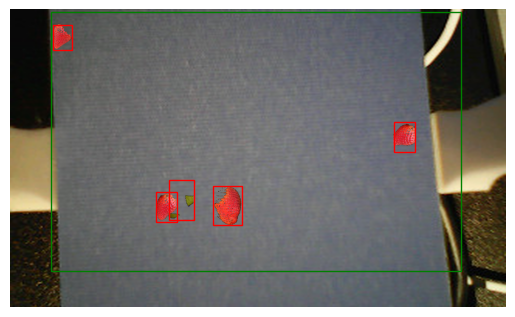

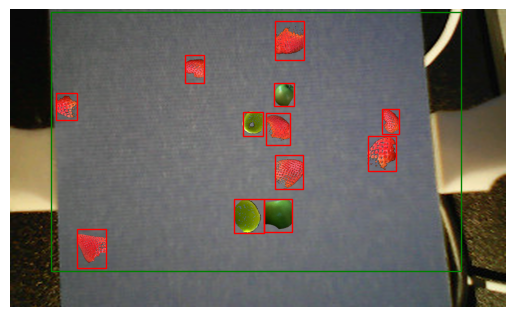

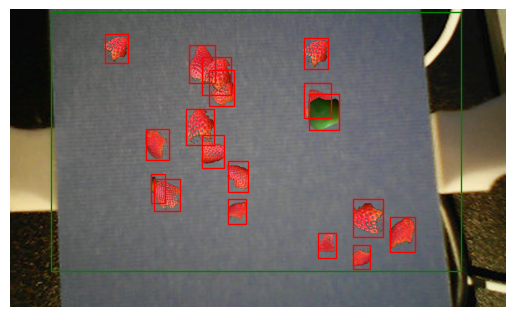

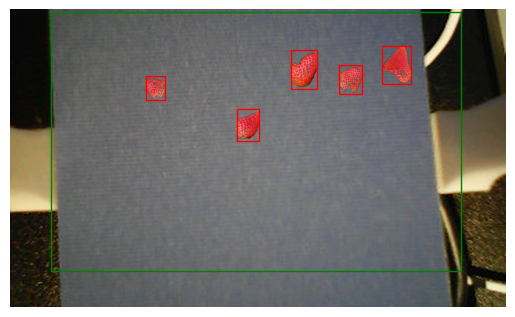

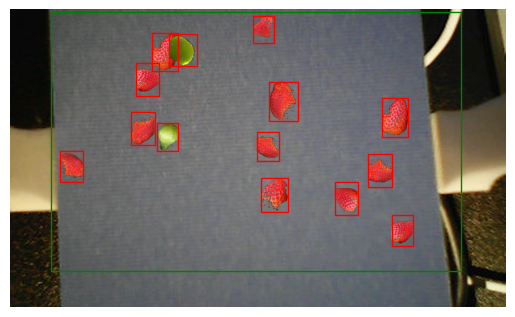

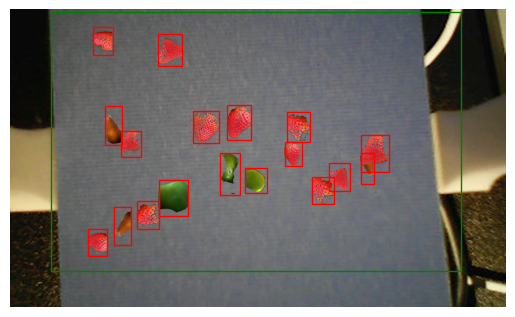

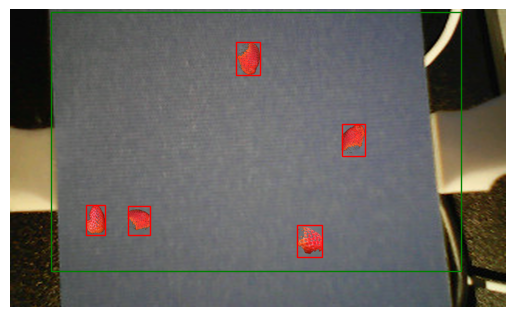

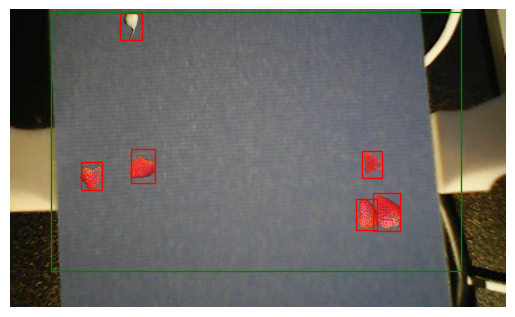

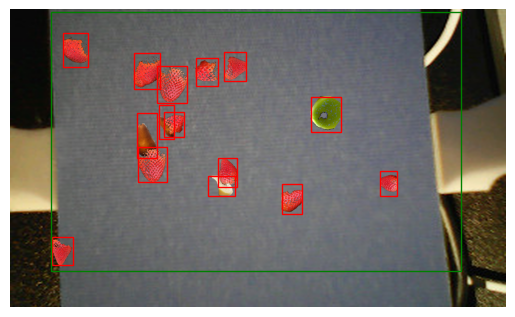

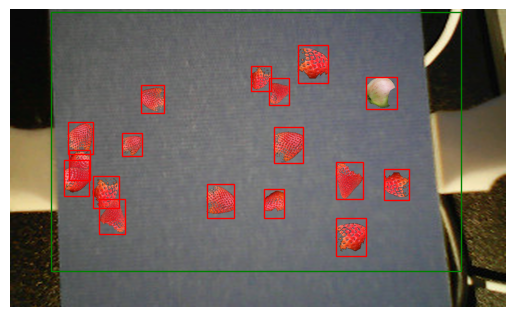

In [ ]:
import json
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from pycocotools import mask as mask_utils
from random import randint, choice, uniform
import os
import glob

# Global Parameters (User Specified)
params = {
    "bg_width_cm" : 50,
    "min_scale_cm": 3,
    "max_scale_cm": 5,
    "placement_area": (166, 8, 1654, 1048),
    "rotation_range": (-30, 30),
    "allow_overlap": True,
    "max_overlap_pct": 0.5,
    "anomaly_probability": 0.2,
    "number_of_objects_per_image": (5,20)
}

# Preload Backgrounds and Objects
backgrounds = []
objects = {}
anomaly_objects = {}

def preload_images(base_path, categories, anomaly_categories):
    global backgrounds, objects, anomaly_objects

    backgrounds = glob.glob(f'{base_path}/backgrounds/*.png')

    for category in categories:
        image_files = glob.glob(f'{base_path}/{category}/*.png')
        if image_files:
            objects[category] = {'images': image_files}

    for anomaly in anomaly_categories:
        image_files = glob.glob(f'{base_path}/{anomaly}/*.png')
        if image_files:
            anomaly_objects[anomaly] = {'images': image_files}



@tf.function
def _rotate_image_helper(image, angle, interpolation='NEAREST'):
    height, width = tf.cast(tf.shape(image)[0], tf.float32), tf.cast(tf.shape(image)[1], tf.float32)
    center_y, center_x = height / 2, width / 2

    # Define the rotation matrix components
    cos_angle = tf.cos(angle)
    sin_angle = tf.sin(angle)

    # Ensure all tensors have the correct shape
    cos_angle = tf.reshape(cos_angle, [1])
    sin_angle = tf.reshape(sin_angle, [1])
    center_x = tf.reshape(center_x, [1])
    center_y = tf.reshape(center_y, [1])

    # Construct the transformation matrix for rotation around the image center
    transform = tf.concat([
        cos_angle, -sin_angle, center_x - center_x * cos_angle + center_y * sin_angle,
        sin_angle, cos_angle, center_y - center_x * sin_angle - center_y * cos_angle,
        [0.0], [0.0]
    ], axis=0)
    transform = tf.reshape(transform, [8])

    # Apply the transformation
    image = tf.expand_dims(image, 0)  # Add batch dimension
    output = tf.raw_ops.ImageProjectiveTransformV2(
        images=image,
        transforms=tf.expand_dims(transform, 0),
        output_shape=[tf.cast(height, tf.int32), tf.cast(width, tf.int32)],
        interpolation=interpolation.upper()
    )
    return tf.squeeze(output, 0)  # Remove batch dimension



def calculate_diagonal(height, width):
    """Calculate the diagonal of an image."""
    return tf.sqrt(tf.square(tf.cast(height, tf.float32)) + tf.square(tf.cast(width, tf.float32)))


def resize_and_rotate(image, min_size, max_size, bg_ppcm):
    obj_height = tf.shape(image)[0]
    obj_width = tf.shape(image)[1]
    original_diag = calculate_diagonal(obj_height, obj_width)


    target_diag_cm = uniform(min_size, max_size)
    target_diag_px = tf.cast(target_diag_cm * bg_ppcm, tf.float32)
    scale_factor = target_diag_px / original_diag


    new_height = tf.maximum(tf.cast(tf.shape(image)[0], tf.float32) * scale_factor, 1.0)
    new_width = tf.maximum(tf.cast(tf.shape(image)[1], tf.float32) * scale_factor, 1.0)

    img_resized = tf.image.resize(
        image,
        [tf.cast(new_height, tf.int32), tf.cast(new_width, tf.int32)]
    )
    # img_resized = tf.image.resize(
    #     image,
    #     [tf.cast(tf.cast(tf.shape(image)[0], tf.float32) * scale_factor, tf.int32),
    #     tf.cast(tf.cast(tf.shape(image)[1], tf.float32) * scale_factor, tf.int32)]
    # )
    angle = tf.random.uniform([], *params['rotation_range'])
    img_rotated = _rotate_image_helper(img_resized, angle, interpolation='nearest')
    return img_rotated

# Load masked image
def load_masked_image(image_path):
    try:
        image = tf.io.read_file(image_path)
        return tf.image.decode_png(image, channels=3)
    except Exception as e:
        print(f"Error loading image {image_path}: {e}")
        return None

# Place object on background
def place_object(background, obj_image, x, y):
    bg_h, bg_w = tf.shape(background)[0], tf.shape(background)[1]
    obj_image_padded = tf.image.pad_to_bounding_box(obj_image, y, x, bg_h, bg_w)
    blended_canvas = tf.where(obj_image_padded > 0, tf.cast(obj_image_padded, tf.float32), tf.cast(background, tf.float32))
    return tf.cast(blended_canvas, tf.uint8)

# Composite image generation
def create_composite_image(num_images, bg_image_path, output_folder):
    global anomaly_objects  # Explicitly reference the global anomaly_objects
    bg_width_cm = params['bg_width_cm']

    # Remove empty keys from anomaly_objects (in-place)
    anomaly_objects = {
        key: value for key, value in anomaly_objects.items() if value['images']
    }

    global objects  # Reference global objects
    objects = {
        key: value for key, value in objects.items() if value['images']
    }
    if len(objects) == 0:
        print("No valid objects found. Exiting.")
        return

    for i in range(num_images):
        bg_image = tf.io.read_file(bg_image_path)
        bg_image = tf.image.decode_png(bg_image, channels=3)
        bg_height_px, bg_width_px = tf.shape(bg_image)[:2]
        bg_ppcm = bg_width_px / bg_width_cm


        existing_bboxes = []
        annotation_data = []
        num_objects = randint(params['number_of_objects_per_image'][0], params['number_of_objects_per_image'][1])

        for obj_id in range(num_objects):
            use_anomaly = uniform(0, 1) < params['anomaly_probability']
            category_pool = anomaly_objects if (use_anomaly and len(anomaly_objects) > 0)  else objects
            category = choice(list(category_pool.keys()))
            item = choice(category_pool[category]['images'])
            obj_image = load_masked_image(item)
            obj_image = resize_and_rotate(obj_image, params['min_scale_cm'], params['max_scale_cm'], bg_ppcm)




            placed = False
            x_min, y_min, x_max, y_max = params['placement_area']
            retry_count = 0
            max_retries = 10

            while not placed and retry_count < max_retries:
                obj_height = int(tf.shape(obj_image)[0])
                obj_width = int(tf.shape(obj_image)[1])
                if obj_width > (x_max - x_min) or obj_height > (y_max - y_min):
                    retry_count += 1
                    print(f"Skipping object {obj_id} due to size exceeding placement area.")
                    continue


                x = randint(x_min, x_max - obj_width)
                y = randint(y_min, y_max - obj_height)

                if params['allow_overlap']:
                  if not check_overlap(existing_bboxes, [x, y, obj_width, obj_height], params['max_overlap_pct']):
                    placed = True

                else:
                  if not check_overlap(existing_bboxes, [x, y, obj_width, obj_height], 0):
                      placed = True


                if placed:
                    gray_image = tf.image.rgb_to_grayscale(obj_image)
                    binary_mask = np.where(gray_image.numpy() > 0, 1, 0).astype(np.uint8)

                    binary_mask = np.asfortranarray(binary_mask)
                    rle = mask_utils.encode(binary_mask)
                    bbox = [x, y, obj_width, obj_height]

                    annotation_data.append({
                        "id": int(obj_id),
                        "label_id": category,
                        "bbox": [int(x), int(y), int(obj_width), int(obj_height)],

                    })

                    bg_image = place_object(bg_image, obj_image, x, y)
                    existing_bboxes.append(bbox)

                retry_count += 1

            if retry_count >= max_retries:
                print(f"Skipping object {obj_id} due to overlap issues.")
                continue
        composite = tf.io.encode_jpeg(bg_image)
        random_id = str(uuid4())[:8]
        tf.io.write_file(os.path.join(output_folder, f'synth_{random_id}.jpg'), composite)
        with open(os.path.join(output_folder, f'synth_{random_id}.json'), 'w') as f:
             json.dump(annotation_data, f)

        plt.imshow(bg_image.numpy())
        for bbox in existing_bboxes:
            x, y, w, h = bbox
            plt.gca().add_patch(plt.Rectangle((x, y), w, h, edgecolor='red', facecolor='none'))
        plt.gca().add_patch(plt.Rectangle((params['placement_area'][0], params['placement_area'][1]), params['placement_area'][2], params['placement_area'][3], edgecolor='green', facecolor='none'))
        plt.axis('off')
        plt.show()

# Check overlap between bounding boxes
def check_overlap(existing_bboxes, new_bbox, max_iou):
    for bbox in existing_bboxes:
        if calculate_iou(bbox, new_bbox) > max_iou:
            return True
    return False

# Calculate IoU
def calculate_iou(box1, box2):
    x1, y1, w1, h1 = box1
    x2, y2, w2, h2 = box2
    inter_x1 = max(x1, x2)
    inter_y1 = max(y1, y2)
    inter_x2 = min(x1 + w1, x2 + w2)
    inter_y2 = min(y1 + h1, y2 + h2)
    inter_area = max(0, inter_x2 - inter_x1) * max(0, inter_y2 - inter_y1)
    box1_area = w1 * h1
    box2_area = w2 * h2
    return inter_area / (box1_area + box2_area - inter_area)



if __name__ == "__main__":
    # Paths
    base_path = '/content/new_extracted_objects'
    bg_image_path = '/content/resized_empty7.png'
    output_folder = '/content/composite_images/strawberries_with_anomaly'
    categories = ['Red_strawberries']
    anomaly_categories = ['Pear', 'Apple' ]
    # Example usage




    os.makedirs(output_folder, exist_ok=True)
    preload_images(base_path, categories, anomaly_categories)
    create_composite_image(10, bg_image_path, output_folder)


In [ ]:
!zip -r /content/composite_images.zip /content/composite_images

#Test

##optimized image composition

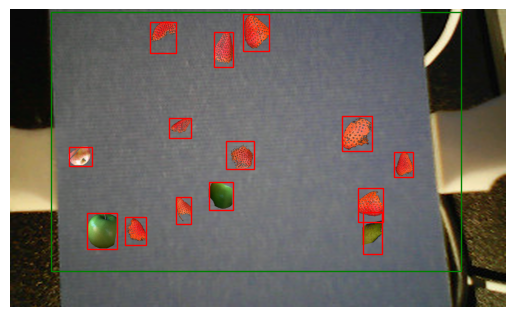

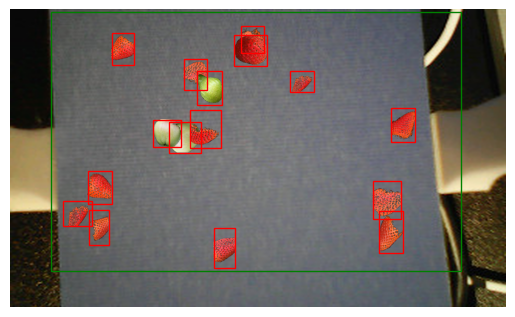

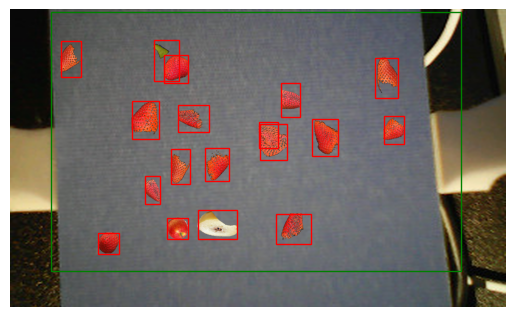

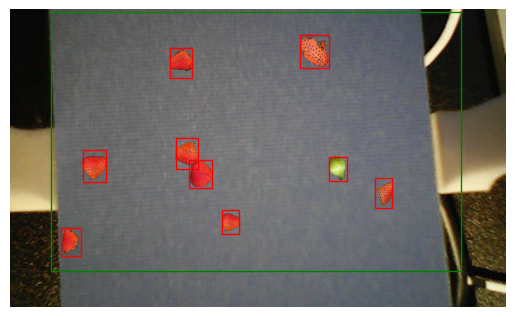

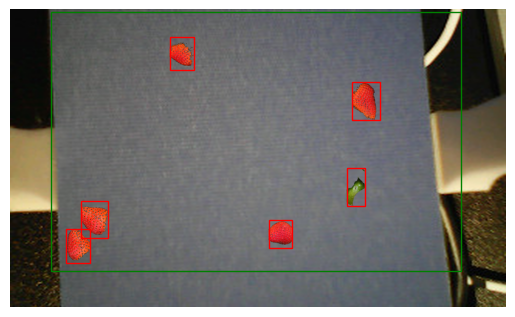

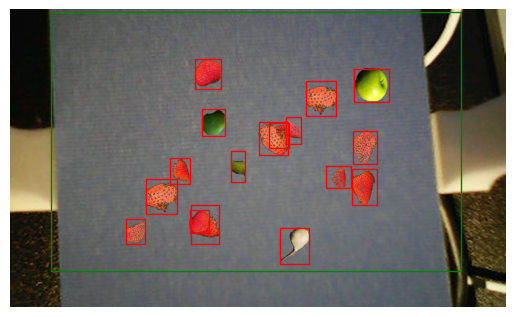

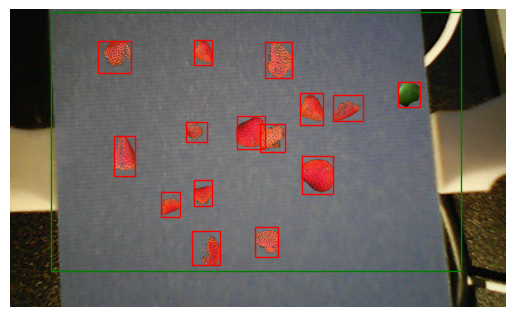

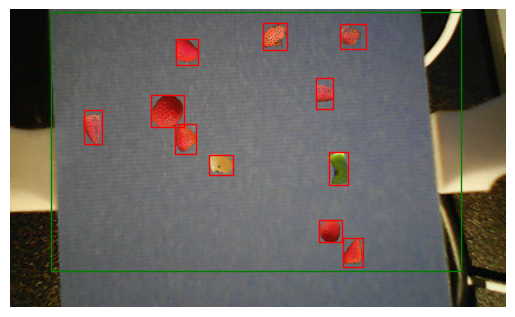

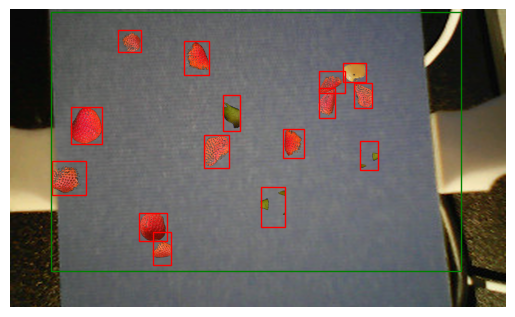

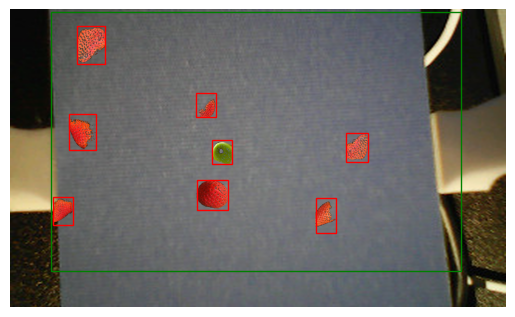

In [ ]:
import json
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from pycocotools import mask as mask_utils
from random import randint, choice, uniform
import os
import glob
from uuid import uuid4

# Global Parameters (User Specified)
params = {
    "bg_width_cm": 50,
    "min_scale_cm": 3,
    "max_scale_cm": 5,
    "placement_area": (166, 8, 1654, 1048),
    "rotation_range": (-30, 30),
    "allow_overlap": True,
    "max_overlap_pct": 0.5,
    "anomaly_probability": 0.2,
    "number_of_objects_per_image": (5, 20)
}

# Preload Backgrounds and Objects
backgrounds = []
objects = {}
anomaly_objects = {}

def preload_images(base_path, categories, anomaly_categories):
    global backgrounds, objects, anomaly_objects

    backgrounds = glob.glob(f'{base_path}/backgrounds/*.png')

    for category in categories:
        image_files = glob.glob(f'{base_path}/{category}/*.png')
        if image_files:
            objects[category] = {'images': image_files}

    for anomaly in anomaly_categories:
        image_files = glob.glob(f'{base_path}/{anomaly}/*.png')
        if image_files:
            anomaly_objects[anomaly] = {'images': image_files}

@tf.function
def _rotate_image_helper(image, angle, interpolation='NEAREST'):
    height, width = tf.cast(tf.shape(image)[0], tf.float32), tf.cast(tf.shape(image)[1], tf.float32)
    center_y, center_x = height / 2, width / 2

    cos_angle = tf.cos(angle)
    sin_angle = tf.sin(angle)

    cos_angle = tf.reshape(cos_angle, [1])
    sin_angle = tf.reshape(sin_angle, [1])
    center_x = tf.reshape(center_x, [1])
    center_y = tf.reshape(center_y, [1])

    transform = tf.concat([
        cos_angle, -sin_angle, center_x - center_x * cos_angle + center_y * sin_angle,
        sin_angle, cos_angle, center_y - center_x * sin_angle - center_y * cos_angle,
        [0.0], [0.0]
    ], axis=0)
    transform = tf.reshape(transform, [8])

    image = tf.expand_dims(image, 0)
    output = tf.raw_ops.ImageProjectiveTransformV2(
        images=image,
        transforms=tf.expand_dims(transform, 0),
        output_shape=[tf.cast(height, tf.int32), tf.cast(width, tf.int32)],
        interpolation=interpolation.upper()
    )
    return tf.squeeze(output, 0)

def calculate_diagonal(height, width):
    return tf.sqrt(tf.square(tf.cast(height, tf.float32)) + tf.square(tf.cast(width, tf.float32)))

def resize_and_rotate(image, min_size, max_size, bg_ppcm):
    obj_height = tf.shape(image)[0]
    obj_width = tf.shape(image)[1]
    original_diag = calculate_diagonal(obj_height, obj_width)

    target_diag_cm = uniform(min_size, max_size)
    target_diag_px = tf.cast(target_diag_cm * bg_ppcm, tf.float32)
    scale_factor = target_diag_px / original_diag

    new_height = tf.maximum(tf.cast(tf.shape(image)[0], tf.float32) * scale_factor, 1.0)
    new_width = tf.maximum(tf.cast(tf.shape(image)[1], tf.float32) * scale_factor, 1.0)

    img_resized = tf.image.resize(
        image,
        [tf.cast(new_height, tf.int32), tf.cast(new_width, tf.int32)]
    )
    angle = tf.random.uniform([], *params['rotation_range'])
    img_rotated = _rotate_image_helper(img_resized, angle, interpolation='nearest')
    return img_rotated

def load_masked_image(image_path):
    try:
        image = tf.io.read_file(image_path)
        return tf.image.decode_png(image, channels=3)
    except Exception as e:
        print(f"Error loading image {image_path}: {e}")
        return None

def place_object(background, obj_image, x, y):
    bg_h, bg_w = tf.shape(background)[0], tf.shape(background)[1]
    obj_image_padded = tf.image.pad_to_bounding_box(obj_image, y, x, bg_h, bg_w)
    blended_canvas = tf.where(obj_image_padded > 0, tf.cast(obj_image_padded, tf.float32), tf.cast(background, tf.float32))
    return tf.cast(blended_canvas, tf.uint8)

def create_composite_image(num_images, bg_image_path, output_folder):
    global anomaly_objects, objects

    anomaly_objects = {key: value for key, value in anomaly_objects.items() if value['images']}
    objects = {key: value for key, value in objects.items() if value['images']}

    if len(objects) == 0:
        print("No valid objects found. Exiting.")
        return

    for i in range(num_images):
        bg_image = tf.io.read_file(bg_image_path)
        bg_image = tf.image.decode_png(bg_image, channels=3)
        bg_height_px, bg_width_px = tf.shape(bg_image)[:2]
        bg_ppcm = bg_width_px / params['bg_width_cm']

        existing_bboxes = []
        annotation_data = []
        num_objects = randint(params['number_of_objects_per_image'][0], params['number_of_objects_per_image'][1])

        for obj_id in range(num_objects):
            use_anomaly = uniform(0, 1) < params['anomaly_probability']
            category_pool = anomaly_objects if (use_anomaly and len(anomaly_objects) > 0) else objects
            category = choice(list(category_pool.keys()))
            item = choice(category_pool[category]['images'])
            obj_image = load_masked_image(item)
            if obj_image is None:
                continue

            obj_image = resize_and_rotate(obj_image, params['min_scale_cm'], params['max_scale_cm'], bg_ppcm)

            placed = False
            x_min, y_min, x_max, y_max = params['placement_area']
            retry_count = 0
            max_retries = 10

            while not placed and retry_count < max_retries:
                obj_height = int(tf.shape(obj_image)[0])
                obj_width = int(tf.shape(obj_image)[1])
                if obj_width > (x_max - x_min) or obj_height > (y_max - y_min):
                    retry_count += 1
                    print(f"Skipping object {obj_id} due to size exceeding placement area.")
                    continue

                x = randint(x_min, x_max - obj_width)
                y = randint(y_min, y_max - obj_height)

                if params['allow_overlap']:
                    if not check_overlap(existing_bboxes, [x, y, obj_width, obj_height], params['max_overlap_pct']):
                        placed = True
                else:
                    if not check_overlap(existing_bboxes, [x, y, obj_width, obj_height], 0):
                        placed = True

                if placed:
                    gray_image = tf.image.rgb_to_grayscale(obj_image)
                    binary_mask = np.where(gray_image.numpy() > 0, 1, 0).astype(np.uint8)
                    binary_mask = np.asfortranarray(binary_mask)
                    rle = mask_utils.encode(binary_mask)
                    bbox = [x, y, obj_width, obj_height]

                    annotation_data.append({
                        "id": int(obj_id),
                        "label_id": category,
                        "bbox": [int(x), int(y), int(obj_width), int(obj_height)],
                        # "segmentation": rlek
                    })

                    bg_image = place_object(bg_image, obj_image, x, y)
                    existing_bboxes.append(bbox)

                retry_count += 1

            if retry_count >= max_retries:
                print(f"Skipping object {obj_id} due to overlap issues.")
                continue

        composite = tf.io.encode_jpeg(bg_image)
        random_id = str(uuid4())[:8]
        tf.io.write_file(os.path.join(output_folder, f'synth_{random_id}.jpg'), composite)
        with open(os.path.join(output_folder, f'synth_{random_id}.json'), 'w') as f:
            json.dump(annotation_data, f)

        # Visualization (optional)
        plt.imshow(bg_image.numpy())
        for bbox in existing_bboxes:
            x, y, w, h = bbox
            plt.gca().add_patch(plt.Rectangle((x, y), w, h, edgecolor='red', facecolor='none'))
        plt.gca().add_patch(plt.Rectangle((params['placement_area'][0], params['placement_area'][1]), params['placement_area'][2], params['placement_area'][3], edgecolor='green', facecolor='none'))
        plt.axis('off')
        plt.show()

def check_overlap(existing_bboxes, new_bbox, max_iou):
    for bbox in existing_bboxes:
        if calculate_iou(bbox, new_bbox) > max_iou:
            return True
    return False

def calculate_iou(box1, box2):
    x1, y1, w1, h1 = box1
    x2, y2, w2, h2 = box2
    inter_x1 = max(x1, x2)
    inter_y1 = max(y1, y2)
    inter_x2 = min(x1 + w1, x2 + w2)
    inter_y2 = min(y1 + h1, y2 + h2)
    inter_area = max(0, inter_x2 - inter_x1) * max(0, inter_y2 - inter_y1)
    box1_area = w1 * h1
    box2_area = w2 * h2
    return inter_area / (box1_area + box2_area - inter_area)

if __name__ == "__main__":
    # Paths
    base_path = '/content/new_extracted_objects'
    bg_image_path = '/content/resized_empty7.png'
    output_folder = '/content/composite_images/strawberries_with_anomaly'
    categories = ['Red_strawberries']
    anomaly_categories = ['Pear', 'Apple']

    os.makedirs(output_folder, exist_ok=True)
    preload_images(base_path, categories, anomaly_categories)
    create_composite_image(10, bg_image_path, output_folder)

##Video Generation

In [ ]:
import json
import cv2
import numpy as np
import tensorflow as tf
from random import randint, choice, uniform
import os
from uuid import uuid4
from pycocotools import mask as mask_utils

# Global Parameters (User Specified)
params = {
    "bg_width_cm": 50,
    "min_scale_cm": 3,
    "max_scale_cm": 5,
    "placement_area": (166, 8, 1654, 1048),  # (x_min, y_min, x_max, y_max)
    "rotation_range": (-30, 30),
    "allow_overlap": False,
    "max_overlap_pct": 0.5,
    "anomaly_probability": 0.2,
    "number_of_objects_per_frame": (1, 3),  # Number of objects to add per frame
    "total_videos": 1,  # Number of short videos to generate
    "video_duration_sec": 3,  # Duration of each video in seconds
    "fps": 10,  # Frames per second for the video
    "y_increment": 10,  # How much to move objects downward in each frame
    "output_video_folder": "/content/videos",  # Folder to save the videos
    "output_frame_folder": "/content/frames",  # Folder to save individual frames (optional)
}

# Preload Backgrounds and Objects
backgrounds = []
objects = {}
anomaly_objects = {}

def preload_images(base_path, categories, anomaly_categories):
    global backgrounds, objects, anomaly_objects

    backgrounds = glob.glob(f'{base_path}/backgrounds/*.png')

    for category in categories:
        image_files = glob.glob(f'{base_path}/{category}/*.png')
        if image_files:
            objects[category] = {'images': image_files}

    for anomaly in anomaly_categories:
        image_files = glob.glob(f'{base_path}/{anomaly}/*.png')
        if image_files:
            anomaly_objects[anomaly] = {'images': image_files}

@tf.function
def _rotate_image_helper(image, angle, interpolation='NEAREST'):
    height, width = tf.cast(tf.shape(image)[0], tf.float32), tf.cast(tf.shape(image)[1], tf.float32)
    center_y, center_x = height / 2, width / 2

    cos_angle = tf.cos(angle)
    sin_angle = tf.sin(angle)

    cos_angle = tf.reshape(cos_angle, [1])
    sin_angle = tf.reshape(sin_angle, [1])
    center_x = tf.reshape(center_x, [1])
    center_y = tf.reshape(center_y, [1])

    transform = tf.concat([
        cos_angle, -sin_angle, center_x - center_x * cos_angle + center_y * sin_angle,
        sin_angle, cos_angle, center_y - center_x * sin_angle - center_y * cos_angle,
        [0.0], [0.0]
    ], axis=0)
    transform = tf.reshape(transform, [8])

    image = tf.expand_dims(image, 0)
    output = tf.raw_ops.ImageProjectiveTransformV2(
        images=image,
        transforms=tf.expand_dims(transform, 0),
        output_shape=[tf.cast(height, tf.int32), tf.cast(width, tf.int32)],
        interpolation=interpolation.upper()
    )
    return tf.squeeze(output, 0)

def calculate_diagonal(height, width):
    return tf.sqrt(tf.square(tf.cast(height, tf.float32)) + tf.square(tf.cast(width, tf.float32)))

def resize_and_rotate(image, min_size, max_size, bg_ppcm):
    obj_height = tf.shape(image)[0]
    obj_width = tf.shape(image)[1]
    original_diag = calculate_diagonal(obj_height, obj_width)

    target_diag_cm = uniform(min_size, max_size)
    target_diag_px = tf.cast(target_diag_cm * bg_ppcm, tf.float32)
    scale_factor = target_diag_px / original_diag

    new_height = tf.maximum(tf.cast(tf.shape(image)[0], tf.float32) * scale_factor, 1.0)
    new_width = tf.maximum(tf.cast(tf.shape(image)[1], tf.float32) * scale_factor, 1.0)

    img_resized = tf.image.resize(
        image,
        [tf.cast(new_height, tf.int32), tf.cast(new_width, tf.int32)]
    )
    angle = tf.random.uniform([], *params['rotation_range'])
    img_rotated = _rotate_image_helper(img_resized, angle, interpolation='nearest')
    return img_rotated

def load_masked_image(image_path):
    try:
        image = tf.io.read_file(image_path)
        return tf.image.decode_png(image, channels=3)
    except Exception as e:
        print(f"Error loading image {image_path}: {e}")
        return None

def place_object(background, obj_image, x, y):
    bg_h, bg_w = tf.shape(background)[0], tf.shape(background)[1]
    obj_image_padded = tf.image.pad_to_bounding_box(obj_image, y, x, bg_h, bg_w)
    blended_canvas = tf.where(obj_image_padded > 0, tf.cast(obj_image_padded, tf.float32), tf.cast(background, tf.float32))
    return tf.cast(blended_canvas, tf.uint8)

def create_conveyor_belt_video(bg_image_path, output_folder, video_idx):
    global anomaly_objects, objects

    anomaly_objects = {key: value for key, value in anomaly_objects.items() if value['images']}
    objects = {key: value for key, value in objects.items() if value['images']}

    if len(objects) == 0:
        print("No valid objects found. Exiting.")
        return

    # Load background image
    bg_image = tf.io.read_file(bg_image_path)
    bg_image = tf.image.decode_png(bg_image, channels=3)
    bg_height_px, bg_width_px = tf.shape(bg_image)[:2]
    bg_ppcm = bg_width_px / params['bg_width_cm']

    # Calculate number of frames for the video
    frame_count = params['video_duration_sec'] * params['fps']

    # Initialize video writer
    video_path = os.path.join(output_folder, f'video_{video_idx:04d}.mp4')
    video_writer = cv2.VideoWriter(
        video_path,
        cv2.VideoWriter_fourcc(*'mp4v'),
        params['fps'],
        (bg_width_px.numpy(), bg_height_px.numpy())
    )

    # List to store all objects on the conveyor belt
    conveyor_objects = []
    print(frame_count)
    for frame_idx in range(frame_count):
        print(frame_idx)
        frame = bg_image.numpy().copy()

        # Add new objects to the conveyor belt
        num_new_objects = randint(params['number_of_objects_per_frame'][0], params['number_of_objects_per_frame'][1])
        for _ in range(num_new_objects):
            use_anomaly = uniform(0, 1) < params['anomaly_probability']
            category_pool = anomaly_objects if (use_anomaly and len(anomaly_objects) > 0) else objects
            category = choice(list(category_pool.keys()))
            item = choice(category_pool[category]['images'])
            obj_image = load_masked_image(item)
            if obj_image is None:
                continue

            obj_image = resize_and_rotate(obj_image, params['min_scale_cm'], params['max_scale_cm'], bg_ppcm)
            obj_height = int(tf.shape(obj_image)[0])
            obj_width = int(tf.shape(obj_image)[1])

            x = randint(params['placement_area'][0], params['placement_area'][2] - obj_width)
            y = 0  # Start at the top of the conveyor belt

            conveyor_objects.append({
                "image": obj_image,
                "x": x,
                "y": y,
                "width": obj_width,
                "height": obj_height
            })

        # Move all objects downward
        for obj in conveyor_objects:
            obj["y"] += params['y_increment']
            frame = place_object(frame, obj["image"], obj["x"], obj["y"])

        # Convert frame to a NumPy array
        frame_np = frame.numpy()  # Convert TensorFlow tensor to NumPy array

        # Write frame to video
        video_writer.write(cv2.cvtColor(frame_np, cv2.COLOR_RGB2BGR))

    video_writer.release()
    print(f"Video saved to {video_path}")

if __name__ == "__main__":
    # Paths
    base_path = '/content/new_extracted_objects'
    bg_image_path = '/content/resized_empty7.png'
    output_video_folder = params['output_video_folder']
    output_frame_folder = params['output_frame_folder']
    categories = ['Red_strawberries']
    anomaly_categories = ['Pear', 'Apple']

    os.makedirs(output_video_folder, exist_ok=True)
    os.makedirs(output_frame_folder, exist_ok=True)
    preload_images(base_path, categories, anomaly_categories)

    # Generate multiple short videos
    for video_idx in range(params['total_videos']):
        create_conveyor_belt_video(bg_image_path, output_video_folder, video_idx)

30
0
1


2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
Video saved to /content/videos/video_0000.mp4


with overlap check random place ment

In [ ]:
import json
import glob
import cv2
import numpy as np
import tensorflow as tf
from random import randint, choice, uniform
import os
from uuid import uuid4
from pycocotools import mask as mask_utils

# Global Parameters (User Specified)
params = {
    "bg_width_cm": 50,
    "min_scale_cm": 3,
    "max_scale_cm": 5,
    "placement_area": (166, 8, 1654, 1048),  # (x_min, y_min, x_max, y_max)
    "rotation_range": (-30, 30),
    "allow_overlap": False,
    "max_overlap_pct": 0.5,
    "anomaly_probability": 0.2,
    "number_of_objects_per_frame": (1, 3),  # Number of objects to add per frame
    "total_videos": 3,  # Number of short videos to generate
    "video_duration_sec": 3,  # Duration of each video in seconds
    "fps": 10,  # Frames per second for the video
    "y_increment": 25,  # How much to move objects downward in each frame
    "output_video_folder": "/content/videos",  # Folder to save the videos
    "output_frame_folder": "/content/frames",  # Folder to save individual frames (optional)
}

# Preload Backgrounds and Objects
backgrounds = []
objects = {}
anomaly_objects = {}

def preload_images(base_path, categories, anomaly_categories):
    global backgrounds, objects, anomaly_objects

    backgrounds = glob.glob(f'{base_path}/backgrounds/*.png')

    for category in categories:
        image_files = glob.glob(f'{base_path}/{category}/*.png')
        if image_files:
            objects[category] = {'images': image_files}

    for anomaly in anomaly_categories:
        image_files = glob.glob(f'{base_path}/{anomaly}/*.png')
        if image_files:
            anomaly_objects[anomaly] = {'images': image_files}

@tf.function
def _rotate_image_helper(image, angle, interpolation='NEAREST'):
    height, width = tf.cast(tf.shape(image)[0], tf.float32), tf.cast(tf.shape(image)[1], tf.float32)
    center_y, center_x = height / 2, width / 2

    cos_angle = tf.cos(angle)
    sin_angle = tf.sin(angle)

    cos_angle = tf.reshape(cos_angle, [1])
    sin_angle = tf.reshape(sin_angle, [1])
    center_x = tf.reshape(center_x, [1])
    center_y = tf.reshape(center_y, [1])

    transform = tf.concat([
        cos_angle, -sin_angle, center_x - center_x * cos_angle + center_y * sin_angle,
        sin_angle, cos_angle, center_y - center_x * sin_angle - center_y * cos_angle,
        [0.0], [0.0]
    ], axis=0)
    transform = tf.reshape(transform, [8])

    image = tf.expand_dims(image, 0)
    output = tf.raw_ops.ImageProjectiveTransformV2(
        images=image,
        transforms=tf.expand_dims(transform, 0),
        output_shape=[tf.cast(height, tf.int32), tf.cast(width, tf.int32)],
        interpolation=interpolation.upper()
    )
    return tf.squeeze(output, 0)

def calculate_diagonal(height, width):
    return tf.sqrt(tf.square(tf.cast(height, tf.float32)) + tf.square(tf.cast(width, tf.float32)))

def resize_and_rotate(image, min_size, max_size, bg_ppcm):
    obj_height = tf.shape(image)[0]
    obj_width = tf.shape(image)[1]
    original_diag = calculate_diagonal(obj_height, obj_width)

    target_diag_cm = uniform(min_size, max_size)
    target_diag_px = tf.cast(target_diag_cm * bg_ppcm, tf.float32)
    scale_factor = target_diag_px / original_diag

    new_height = tf.maximum(tf.cast(tf.shape(image)[0], tf.float32) * scale_factor, 1.0)
    new_width = tf.maximum(tf.cast(tf.shape(image)[1], tf.float32) * scale_factor, 1.0)

    img_resized = tf.image.resize(
        image,
        [tf.cast(new_height, tf.int32), tf.cast(new_width, tf.int32)]
    )
    angle = tf.random.uniform([], *params['rotation_range'])
    img_rotated = _rotate_image_helper(img_resized, angle, interpolation='nearest')
    return img_rotated

def load_masked_image(image_path):
    try:
        image = tf.io.read_file(image_path)
        return tf.image.decode_png(image, channels=3)
    except Exception as e:
        print(f"Error loading image {image_path}: {e}")
        return None

def place_object(background, obj_image, x, y):
    bg_h, bg_w = tf.shape(background)[0], tf.shape(background)[1]
    obj_image_padded = tf.image.pad_to_bounding_box(obj_image, y, x, bg_h, bg_w)
    blended_canvas = tf.where(obj_image_padded > 0, tf.cast(obj_image_padded, tf.float32), tf.cast(background, tf.float32))
    return tf.cast(blended_canvas, tf.uint8)

def check_overlap(existing_bboxes, new_bbox, max_iou):
    """
    Check if the new bounding box overlaps with any existing bounding boxes beyond the allowed threshold.
    """
    for bbox in existing_bboxes:
        if calculate_iou(bbox, new_bbox) > max_iou:
            return True
    return False

def calculate_iou(box1, box2):
    """
    Calculate the Intersection over Union (IoU) between two bounding boxes.
    """
    x1, y1, w1, h1 = box1
    x2, y2, w2, h2 = box2
    inter_x1 = max(x1, x2)
    inter_y1 = max(y1, y2)
    inter_x2 = min(x1 + w1, x2 + w2)
    inter_y2 = min(y1 + h1, y2 + h2)
    inter_area = max(0, inter_x2 - inter_x1) * max(0, inter_y2 - inter_y1)
    box1_area = w1 * h1
    box2_area = w2 * h2
    return inter_area / (box1_area + box2_area - inter_area)

def create_conveyor_belt_video(bg_image_path, output_folder, video_idx):
    global anomaly_objects, objects

    anomaly_objects = {key: value for key, value in anomaly_objects.items() if value['images']}
    objects = {key: value for key, value in objects.items() if value['images']}

    if len(objects) == 0:
        print("No valid objects found. Exiting.")
        return

    # Load background image
    bg_image = tf.io.read_file(bg_image_path)
    bg_image = tf.image.decode_png(bg_image, channels=3)
    bg_height_px, bg_width_px = tf.shape(bg_image)[:2]
    bg_ppcm = bg_width_px / params['bg_width_cm']

    # Calculate number of frames for the video
    frame_count = params['video_duration_sec'] * params['fps']

    # Initialize video writer
    video_path = os.path.join(output_folder, f'video_{video_idx:04d}.mp4')
    video_writer = cv2.VideoWriter(
        video_path,
        cv2.VideoWriter_fourcc(*'mp4v'),
        params['fps'],
        (bg_width_px.numpy(), bg_height_px.numpy())
    )

    # List to store all objects on the conveyor belt
    conveyor_objects = []
    print(frame_count)
    for frame_idx in range(frame_count):
        print(frame_idx)
        frame = bg_image.numpy().copy()

        # Add new objects to the conveyor belt
        num_new_objects = randint(params['number_of_objects_per_frame'][0], params['number_of_objects_per_frame'][1])
        for _ in range(num_new_objects):
            use_anomaly = uniform(0, 1) < params['anomaly_probability']
            category_pool = anomaly_objects if (use_anomaly and len(anomaly_objects) > 0) else objects
            category = choice(list(category_pool.keys()))
            item = choice(category_pool[category]['images'])
            obj_image = load_masked_image(item)
            if obj_image is None:
                continue

            obj_image = resize_and_rotate(obj_image, params['min_scale_cm'], params['max_scale_cm'], bg_ppcm)
            obj_height = int(tf.shape(obj_image)[0])
            obj_width = int(tf.shape(obj_image)[1])

            # Generate random position for the new object
            max_attempts = 10  # Limit the number of attempts to place the object
            placed = False
            for _ in range(max_attempts):
                x = randint(params['placement_area'][0], params['placement_area'][2] - obj_width)
                y = 0  # Start at the top of the conveyor belt

                # Define the new bounding box
                new_bbox = (x, y, obj_width, obj_height)

                # Check for overlap if overlap is not allowed
                if not params['allow_overlap']:
                    existing_bboxes = [(obj['x'], obj['y'], obj['width'], obj['height']) for obj in conveyor_objects]
                    if check_overlap(existing_bboxes, new_bbox, params['max_overlap_pct']):
                        continue  # Try a new position

                # If no overlap or overlap is allowed, place the object
                conveyor_objects.append({
                    "image": obj_image,
                    "x": x,
                    "y": y,
                    "width": obj_width,
                    "height": obj_height
                })
                placed = True
                break

            if not placed:
                print("Failed to place object after max attempts.")

        # Move all objects downward and remove those that have moved out of the frame
        conveyor_objects_to_remove = []
        for obj in conveyor_objects:
            obj["y"] += params['y_increment']

            # Check if the object has moved out of the background bounds
            if obj["y"] + obj["height"] > bg_height_px:
                conveyor_objects_to_remove.append(obj)
                continue

            # Place the object on the frame
            frame = place_object(frame, obj["image"], obj["x"], obj["y"])

        # Remove objects that have moved out of the frame
        for obj in conveyor_objects_to_remove:
            conveyor_objects.remove(obj)

        # Convert frame to a NumPy array
        frame_np = frame.numpy()

        # Write frame to video
        video_writer.write(cv2.cvtColor(frame_np, cv2.COLOR_RGB2BGR))

    video_writer.release()
    print(f"Video saved to {video_path}")
if __name__ == "__main__":
    # Paths
    base_path = '/content/new_extracted_objects'
    bg_image_path = '/content/resized_empty7.png'
    output_video_folder = params['output_video_folder']
    output_frame_folder = params['output_frame_folder']
    categories = ['Red_strawberries']
    anomaly_categories = ['Pear', 'Apple']

    os.makedirs(output_video_folder, exist_ok=True)
    os.makedirs(output_frame_folder, exist_ok=True)
    preload_images(base_path, categories, anomaly_categories)

    # Generate multiple short videos
    for video_idx in range(params['total_videos']):
        create_conveyor_belt_video(bg_image_path, output_video_folder, video_idx)

30
0
1


2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
Video saved to /content/videos/video_0000.mp4
30
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
Video saved to /content/videos/video_0001.mp4
30
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
Video saved to /content/videos/video_0002.mp4


grid based approch

In [ ]:
import json
import cv2
import numpy as np
import tensorflow as tf
from random import randint, choice, uniform
import os
from uuid import uuid4
from pycocotools import mask as mask_utils
import glob

# Global Parameters (User Specified)
params = {
    "bg_width_cm": 50,
    "min_scale_cm": 3,
    "max_scale_cm": 5,
    "placement_area": (166, 8, 1654, 1048),  # (x_min, y_min, x_max, y_max)
    "rotation_range": (-30, 30),
    "allow_overlap": False,
    "max_overlap_pct": 0.5,
    "anomaly_probability": 0.2,
    "number_of_objects_per_frame": (1, 3),  # Number of objects to add per frame
    "total_videos": 1,  # Number of short videos to generate
    "video_duration_sec": 3,  # Duration of each video in seconds
    "fps": 10,  # Frames per second for the video
    "y_increment": 10,  # How much to move objects downward in each frame
    "output_video_folder": "/content/videos",  # Folder to save the videos
    "output_frame_folder": "/content/frames",  # Folder to save individual frames (optional)
}

# Preload Backgrounds and Objects
backgrounds = []
objects = {}
anomaly_objects = {}

def preload_images(base_path, categories, anomaly_categories):
    global backgrounds, objects, anomaly_objects

    backgrounds = glob.glob(f'{base_path}/backgrounds/*.png')

    for category in categories:
        image_files = glob.glob(f'{base_path}/{category}/*.png')
        if image_files:
            objects[category] = {'images': image_files}

    for anomaly in anomaly_categories:
        image_files = glob.glob(f'{base_path}/{anomaly}/*.png')
        if image_files:
            anomaly_objects[anomaly] = {'images': image_files}

@tf.function
def _rotate_image_helper(image, angle, interpolation='NEAREST'):
    height, width = tf.cast(tf.shape(image)[0], tf.float32), tf.cast(tf.shape(image)[1], tf.float32)
    center_y, center_x = height / 2, width / 2

    cos_angle = tf.cos(angle)
    sin_angle = tf.sin(angle)

    cos_angle = tf.reshape(cos_angle, [1])
    sin_angle = tf.reshape(sin_angle, [1])
    center_x = tf.reshape(center_x, [1])
    center_y = tf.reshape(center_y, [1])

    transform = tf.concat([
        cos_angle, -sin_angle, center_x - center_x * cos_angle + center_y * sin_angle,
        sin_angle, cos_angle, center_y - center_x * sin_angle - center_y * cos_angle,
        [0.0], [0.0]
    ], axis=0)
    transform = tf.reshape(transform, [8])

    image = tf.expand_dims(image, 0)
    output = tf.raw_ops.ImageProjectiveTransformV2(
        images=image,
        transforms=tf.expand_dims(transform, 0),
        output_shape=[tf.cast(height, tf.int32), tf.cast(width, tf.int32)],
        interpolation=interpolation.upper()
    )
    return tf.squeeze(output, 0)

def calculate_diagonal(height, width):
    return tf.sqrt(tf.square(tf.cast(height, tf.float32)) + tf.square(tf.cast(width, tf.float32)))

def resize_and_rotate(image, min_size, max_size, bg_ppcm):
    obj_height = tf.shape(image)[0]
    obj_width = tf.shape(image)[1]
    original_diag = calculate_diagonal(obj_height, obj_width)

    target_diag_cm = uniform(min_size, max_size)
    target_diag_px = tf.cast(target_diag_cm * bg_ppcm, tf.float32)
    scale_factor = target_diag_px / original_diag

    new_height = tf.maximum(tf.cast(tf.shape(image)[0], tf.float32) * scale_factor, 1.0)
    new_width = tf.maximum(tf.cast(tf.shape(image)[1], tf.float32) * scale_factor, 1.0)

    img_resized = tf.image.resize(
        image,
        [tf.cast(new_height, tf.int32), tf.cast(new_width, tf.int32)]
    )
    angle = tf.random.uniform([], *params['rotation_range'])
    img_rotated = _rotate_image_helper(img_resized, angle, interpolation='nearest')
    return img_rotated

def load_masked_image(image_path):
    try:
        image = tf.io.read_file(image_path)
        return tf.image.decode_png(image, channels=3)
    except Exception as e:
        print(f"Error loading image {image_path}: {e}")
        return None

def place_object(background, obj_image, x, y):
    bg_h, bg_w = tf.shape(background)[0], tf.shape(background)[1]
    obj_image_padded = tf.image.pad_to_bounding_box(obj_image, y, x, bg_h, bg_w)
    blended_canvas = tf.where(obj_image_padded > 0, tf.cast(obj_image_padded, tf.float32), tf.cast(background, tf.float32))
    return tf.cast(blended_canvas, tf.uint8)

def get_occupied_cells(x, y, width, height, grid_rows, grid_cols, bg_width, bg_height):
    """
    Get the grid cells occupied by an object.
    """
    # Calculate cell size
    cell_width = bg_width / grid_cols
    cell_height = bg_height / grid_rows

    # Determine the grid cells the object occupies
    start_col = int(x // cell_width)
    end_col = int((x + width) // cell_width)
    start_row = int(y // cell_height)
    end_row = int((y + height) // cell_height)

    # Ensure the indices are within the grid bounds
    start_col = max(0, start_col)
    end_col = min(grid_cols - 1, end_col)
    start_row = max(0, start_row)
    end_row = min(grid_rows - 1, end_row)

    # Return the list of occupied cells
    occupied_cells = []
    for row in range(start_row, end_row + 1):
        for col in range(start_col, end_col + 1):
            occupied_cells.append((row, col))
    return occupied_cells

def can_place_object(x, y, width, height, grid, grid_rows, grid_cols, bg_width, bg_height):
    """
    Check if an object can be placed at (x, y) without overlapping existing objects.
    """
    # Get the grid cells the object would occupy
    occupied_cells = get_occupied_cells(x, y, width, height, grid_rows, grid_cols, bg_width, bg_height)

    # Check if any of the cells are already occupied
    for row, col in occupied_cells:
        if grid[row][col]:
            return False  # Overlap detected
    return True  # No overlap

def place_object_on_grid(x, y, width, height, grid, grid_rows, grid_cols, bg_width, bg_height):
    """
    Place an object on the grid and mark its cells as occupied.
    """
    # Get the grid cells the object occupies
    occupied_cells = get_occupied_cells(x, y, width, height, grid_rows, grid_cols, bg_width, bg_height)

    # Mark the cells as occupied
    for row, col in occupied_cells:
        grid[row][col] = True

def create_conveyor_belt_video(bg_image_path, output_folder, video_idx):
    global anomaly_objects, objects

    anomaly_objects = {key: value for key, value in anomaly_objects.items() if value['images']}
    objects = {key: value for key, value in objects.items() if value['images']}

    if len(objects) == 0:
        print("No valid objects found. Exiting.")
        return

    # Load background image
    bg_image = tf.io.read_file(bg_image_path)
    bg_image = tf.image.decode_png(bg_image, channels=3)
    bg_height_px, bg_width_px = tf.shape(bg_image)[:2]
    bg_ppcm = bg_width_px / params['bg_width_cm']

    # Initialize a list to track occupied columns
    occupied_columns = []

    # Calculate number of frames for the video
    frame_count = params['video_duration_sec'] * params['fps']

    # Initialize video writer
    video_path = os.path.join(output_folder, f'video_{video_idx:04d}.mp4')
    video_writer = cv2.VideoWriter(
        video_path,
        cv2.VideoWriter_fourcc(*'mp4v'),
        params['fps'],
        (bg_width_px.numpy(), bg_height_px.numpy())
    )

    # List to store all objects on the conveyor belt
    conveyor_objects = []

    for frame_idx in range(frame_count):
        frame = bg_image.numpy().copy()

        # Add new objects to the conveyor belt
        num_new_objects = randint(params['number_of_objects_per_frame'][0], params['number_of_objects_per_frame'][1])
        for _ in range(num_new_objects):
            use_anomaly = uniform(0, 1) < params['anomaly_probability']
            category_pool = anomaly_objects if (use_anomaly and len(anomaly_objects) > 0) else objects
            category = choice(list(category_pool.keys()))
            item = choice(category_pool[category]['images'])
            obj_image = load_masked_image(item)
            if obj_image is None:
                continue

            obj_image = resize_and_rotate(obj_image, params['min_scale_cm'], params['max_scale_cm'], bg_ppcm)
            obj_height = int(tf.shape(obj_image)[0])
            obj_width = int(tf.shape(obj_image)[1])

            # Generate random position for the new object
            max_attempts = 10  # Limit the number of attempts to place the object
            placed = False
            for _ in range(max_attempts):
                x = randint(params['placement_area'][0], params['placement_area'][2] - obj_width)
                y = 0  # Start at the top of the conveyor belt

                # Check if the object's columns overlap with existing objects
                new_columns = range(x, x + obj_width)
                overlap = False
                for obj in conveyor_objects:
                    existing_columns = range(obj["x"], obj["y"])
                    if set(new_columns).intersection(existing_columns):
                        overlap = True
                        break

                if not overlap:
                    # Place the object and mark its columns as occupied
                    conveyor_objects.append({
                        "image": obj_image,
                        "x": x,
                        "y": y,
                        "width": obj_width,
                        "height": obj_height
                    })
                    placed = True
                    break

            if not placed:
                print("Failed to place object after max attempts.")

        # Move all objects downward and remove those that have moved out of the frame
        conveyor_objects_to_remove = []
        for obj in conveyor_objects:
            obj["y"] += params['y_increment']

            # Check if the object has moved out of the background bounds
            if obj["y"] + obj["height"] > bg_height_px:
                conveyor_objects_to_remove.append(obj)
                continue

            # Place the object on the frame
            frame = place_object(frame, obj["image"], obj["x"], obj["y"])

        # Remove objects that have moved out of the frame
        for obj in conveyor_objects_to_remove:
            conveyor_objects.remove(obj)

        # Convert frame to a NumPy array
        frame_np = frame.numpy()

        # Write frame to video
        video_writer.write(cv2.cvtColor(frame_np, cv2.COLOR_RGB2BGR))

    video_writer.release()
    print(f"Video saved to {video_path}")

if __name__ == "__main__":
    # Paths
    base_path = '/content/new_extracted_objects'
    bg_image_path = '/content/resized_empty7.png'
    output_video_folder = params['output_video_folder']
    output_frame_folder = params['output_frame_folder']
    categories = ['Red_strawberries']
    anomaly_categories = ['Pear', 'Apple']

    os.makedirs(output_video_folder, exist_ok=True)
    os.makedirs(output_frame_folder, exist_ok=True)
    preload_images(base_path, categories, anomaly_categories)

    # Generate multiple short videos
    for video_idx in range(params['total_videos']):
        create_conveyor_belt_video(bg_image_path, output_video_folder, video_idx)

Video saved to /content/videos/video_0000.mp4


In [ ]:
def calculate_grid_size(placement_area, bg_width_cm, max_scale_cm, bg_width_px, bg_height_px):
    """
    Calculate the grid size based on the placement area, background dimensions, and maximum object size.
    """
    # Calculate pixels per centimeter (ppcm)
    bg_ppcm = bg_width_px / bg_width_cm

    # Convert max_scale_cm to pixels
    max_scale_px = max_scale_cm * bg_ppcm

    # Calculate placement area dimensions
    placement_width = placement_area[2] - placement_area[0]  # x_max - x_min
    placement_height = placement_area[3] - placement_area[1]  # y_max - y_min

    # Calculate grid cell size (ensure each cell is at least as large as the largest object)
    cell_size = max_scale_px

    # Calculate number of grid rows and columns
    grid_cols = int(placement_width // cell_size)
    grid_rows = int(placement_height // cell_size)

    # Ensure there is at least 1 row and 1 column
    grid_cols = max(1, grid_cols)
    grid_rows = max(1, grid_rows)

    return grid_rows, grid_cols


def create_conveyor_belt_video(bg_image_path, output_folder, video_idx):
    global anomaly_objects, objects

    anomaly_objects = {key: value for key, value in anomaly_objects.items() if value['images']}
    objects = {key: value for key, value in objects.items() if value['images']}

    if len(objects) == 0:
        print("No valid objects found. Exiting.")
        return

    # Load background image
    bg_image = tf.io.read_file(bg_image_path)
    bg_image = tf.image.decode_png(bg_image, channels=3)
    bg_height_px, bg_width_px = tf.shape(bg_image)[:2]
    bg_ppcm = bg_width_px / params['bg_width_cm']

    # Calculate grid size automatically
    grid_rows, grid_cols = calculate_grid_size(
        params['placement_area'],
        params['bg_width_cm'],
        params['max_scale_cm'],
        bg_width_px.numpy(),
        bg_height_px.numpy()
    )

    # Initialize grid
    grid = [[False for _ in range(grid_cols)] for _ in range(grid_rows)]

    # Calculate number of frames for the video
    frame_count = params['video_duration_sec'] * params['fps']

    # Initialize video writer
    video_path = os.path.join(output_folder, f'video_{video_idx:04d}.mp4')
    video_writer = cv2.VideoWriter(
        video_path,
        cv2.VideoWriter_fourcc(*'mp4v'),
        params['fps'],
        (bg_width_px.numpy(), bg_height_px.numpy())
    )

    # List to store all objects on the conveyor belt
    conveyor_objects = []

    for frame_idx in range(frame_count):
        frame = bg_image.numpy().copy()

        # Add new objects to the conveyor belt
        num_new_objects = randint(params['number_of_objects_per_frame'][0], params['number_of_objects_per_frame'][1])
        for _ in range(num_new_objects):
            use_anomaly = uniform(0, 1) < params['anomaly_probability']
            category_pool = anomaly_objects if (use_anomaly and len(anomaly_objects) > 0) else objects
            category = choice(list(category_pool.keys()))
            item = choice(category_pool[category]['images'])
            obj_image = load_masked_image(item)
            if obj_image is None:
                continue

            obj_image = resize_and_rotate(obj_image, params['min_scale_cm'], params['max_scale_cm'], bg_ppcm)
            obj_height = int(tf.shape(obj_image)[0])
            obj_width = int(tf.shape(obj_image)[1])

            # Generate random position for the new object
            max_attempts = 10  # Limit the number of attempts to place the object
            placed = False
            for _ in range(max_attempts):
                x = randint(params['placement_area'][0], params['placement_area'][2] - obj_width)
                y = 0  # Start at the top of the conveyor belt

                # Check if the object can be placed without overlapping existing objects
                if can_place_object(x, y, obj_width, obj_height, grid, grid_rows, grid_cols, bg_width_px, bg_height_px):
                    # Place the object and mark its cells as occupied
                    place_object_on_grid(x, y, obj_width, obj_height, grid, grid_rows, grid_cols, bg_width_px, bg_height_px)

                    # Add the object to the conveyor belt
                    conveyor_objects.append({
                        "image": obj_image,
                        "x": x,
                        "y": y,
                        "width": obj_width,
                        "height": obj_height
                    })
                    placed = True
                    break

            if not placed:
                print("Failed to place object after max attempts.")

        # Move all objects downward and remove those that have moved out of the frame
        conveyor_objects_to_remove = []
        for obj in conveyor_objects:
            obj["y"] += params['y_increment']

            # Check if the object has moved out of the background bounds
            if obj["y"] + obj["height"] > bg_height_px:
                conveyor_objects_to_remove.append(obj)
                continue

            # Place the object on the frame
            frame = place_object(frame, obj["image"], obj["x"], obj["y"])

        # Remove objects that have moved out of the frame
        for obj in conveyor_objects_to_remove:
            conveyor_objects.remove(obj)

        # Convert frame to a NumPy array
        frame_np = frame  # No need to call .numpy() since frame is already a NumPy array

        # Write frame to video
        video_writer.write(cv2.cvtColor(frame_np, cv2.COLOR_RGB2BGR))

    video_writer.release()
    print(f"Video saved to {video_path}")



if __name__ == "__main__":
    # Paths
    base_path = '/content/new_extracted_objects'
    bg_image_path = '/content/resized_empty7.png'
    output_video_folder = params['output_video_folder']
    output_frame_folder = params['output_frame_folder']
    categories = ['Red_strawberries']
    anomaly_categories = ['Pear', 'Apple']

    os.makedirs(output_video_folder, exist_ok=True)
    os.makedirs(output_frame_folder, exist_ok=True)
    preload_images(base_path, categories, anomaly_categories)

    # Generate multiple short videos
    for video_idx in range(params['total_videos']):
        create_conveyor_belt_video(bg_image_path, output_video_folder, video_idx)

Failed to place object after max attempts.
Failed to place object after max attempts.
Failed to place object after max attempts.
Failed to place object after max attempts.
Failed to place object after max attempts.
Failed to place object after max attempts.
Failed to place object after max attempts.
Failed to place object after max attempts.
Failed to place object after max attempts.
Failed to place object after max attempts.
Failed to place object after max attempts.
Failed to place object after max attempts.
Failed to place object after max attempts.
Failed to place object after max attempts.
Failed to place object after max attempts.
Failed to place object after max attempts.
Failed to place object after max attempts.
Failed to place object after max attempts.
Failed to place object after max attempts.
Failed to place object after max attempts.
Failed to place object after max attempts.
Failed to place object after max attempts.
Failed to place object after max attempts.
Failed to p

##video Generation with spawn area


In [ ]:
import json
import cv2
import numpy as np
import tensorflow as tf
from random import randint, choice, uniform
import os
from uuid import uuid4
from pycocotools import mask as mask_utils

# Global Parameters (User Specified)
params = {
    "bg_width_cm": 50,
    "min_scale_cm": 3,
    "max_scale_cm": 5,
    "placement_area": (166, 8, 1654, 1048),  # (x_min, y_min, x_max, y_max)
    "rotation_range": (-30, 30),
    "allow_overlap": True,
    "max_overlap_pct": 0.5,
    "anomaly_probability": 0.2,
    "number_of_objects_per_frame": (1, 3),  # Number of objects to add per frame
    "total_videos": 5,  # Number of short videos to generate
    "video_duration_sec": 3,  # Duration of each video in seconds
    "fps": 10,  # Frames per second for the video
    "y_increment": 10,  # How much to move objects downward in each frame
    "spawning_area_height": 100,  # Height of the spawning area above the conveyor belt
    "output_video_folder": "/content/videos",  # Folder to save the videos
    "output_frame_folder": "/content/frames",  # Folder to save individual frames (optional)
}

# Preload Backgrounds and Objects
backgrounds = []
objects = {}
anomaly_objects = {}

def preload_images(base_path, categories, anomaly_categories):
    global backgrounds, objects, anomaly_objects

    backgrounds = glob.glob(f'{base_path}/backgrounds/*.png')

    for category in categories:
        image_files = glob.glob(f'{base_path}/{category}/*.png')
        if image_files:
            objects[category] = {'images': image_files}

    for anomaly in anomaly_categories:
        image_files = glob.glob(f'{base_path}/{anomaly}/*.png')
        if image_files:
            anomaly_objects[anomaly] = {'images': image_files}

@tf.function
def _rotate_image_helper(image, angle, interpolation='NEAREST'):
    height, width = tf.cast(tf.shape(image)[0], tf.float32), tf.cast(tf.shape(image)[1], tf.float32)
    center_y, center_x = height / 2, width / 2

    cos_angle = tf.cos(angle)
    sin_angle = tf.sin(angle)

    cos_angle = tf.reshape(cos_angle, [1])
    sin_angle = tf.reshape(sin_angle, [1])
    center_x = tf.reshape(center_x, [1])
    center_y = tf.reshape(center_y, [1])

    transform = tf.concat([
        cos_angle, -sin_angle, center_x - center_x * cos_angle + center_y * sin_angle,
        sin_angle, cos_angle, center_y - center_x * sin_angle - center_y * cos_angle,
        [0.0], [0.0]
    ], axis=0)
    transform = tf.reshape(transform, [8])

    image = tf.expand_dims(image, 0)
    output = tf.raw_ops.ImageProjectiveTransformV2(
        images=image,
        transforms=tf.expand_dims(transform, 0),
        output_shape=[tf.cast(height, tf.int32), tf.cast(width, tf.int32)],
        interpolation=interpolation.upper()
    )
    return tf.squeeze(output, 0)

def calculate_diagonal(height, width):
    return tf.sqrt(tf.square(tf.cast(height, tf.float32)) + tf.square(tf.cast(width, tf.float32)))

def resize_and_rotate(image, min_size, max_size, bg_ppcm):
    obj_height = tf.shape(image)[0]
    obj_width = tf.shape(image)[1]
    original_diag = calculate_diagonal(obj_height, obj_width)

    target_diag_cm = uniform(min_size, max_size)
    target_diag_px = tf.cast(target_diag_cm * bg_ppcm, tf.float32)
    scale_factor = target_diag_px / original_diag

    new_height = tf.maximum(tf.cast(tf.shape(image)[0], tf.float32) * scale_factor, 1.0)
    new_width = tf.maximum(tf.cast(tf.shape(image)[1], tf.float32) * scale_factor, 1.0)

    img_resized = tf.image.resize(
        image,
        [tf.cast(new_height, tf.int32), tf.cast(new_width, tf.int32)]
    )
    angle = tf.random.uniform([], *params['rotation_range'])
    img_rotated = _rotate_image_helper(img_resized, angle, interpolation='nearest')
    return img_rotated

def load_masked_image(image_path):
    try:
        image = tf.io.read_file(image_path)
        return tf.image.decode_png(image, channels=3)
    except Exception as e:
        print(f"Error loading image {image_path}: {e}")
        return None

def place_object(background, obj_image, x, y):
    bg_h, bg_w = tf.shape(background)[0], tf.shape(background)[1]

    # Skip rendering if the object is above the visible area (y < 0)
    if y < 0:
        return background

    obj_image_padded = tf.image.pad_to_bounding_box(obj_image, y, x, bg_h, bg_w)
    blended_canvas = tf.where(obj_image_padded > 0, tf.cast(obj_image_padded, tf.float32), tf.cast(background, tf.float32))
    return tf.cast(blended_canvas, tf.uint8).numpy()  # Convert to NumPy array

def create_conveyor_belt_video(bg_image_path, output_folder, video_idx):
    global anomaly_objects, objects

    anomaly_objects = {key: value for key, value in anomaly_objects.items() if value['images']}
    objects = {key: value for key, value in objects.items() if value['images']}

    if len(objects) == 0:
        print("No valid objects found. Exiting.")
        return

    # Load background image
    bg_image = tf.io.read_file(bg_image_path)
    bg_image = tf.image.decode_png(bg_image, channels=3)
    bg_height_px, bg_width_px = tf.shape(bg_image)[:2]
    bg_ppcm = bg_width_px / params['bg_width_cm']

    # Calculate number of frames for the video
    frame_count = params['video_duration_sec'] * params['fps']

    # Initialize video writer
    video_path = os.path.join(output_folder, f'video_{video_idx:04d}.mp4')
    video_writer = cv2.VideoWriter(
        video_path,
        cv2.VideoWriter_fourcc(*'mp4v'),
        params['fps'],
        (bg_width_px.numpy(), bg_height_px.numpy())
    )

    # List to store all objects on the conveyor belt
    conveyor_objects = []

    for frame_idx in range(frame_count):
        frame = bg_image.numpy().copy()  # frame is already a NumPy array

        # Add new objects to the spawning area
        num_new_objects = randint(params['number_of_objects_per_frame'][0], params['number_of_objects_per_frame'][1])
        for _ in range(num_new_objects):
            use_anomaly = uniform(0, 1) < params['anomaly_probability']
            category_pool = anomaly_objects if (use_anomaly and len(anomaly_objects) > 0) else objects
            category = choice(list(category_pool.keys()))
            item = choice(category_pool[category]['images'])
            obj_image = load_masked_image(item)
            if obj_image is None:
                continue

            obj_image = resize_and_rotate(obj_image, params['min_scale_cm'], params['max_scale_cm'], bg_ppcm)
            obj_height = int(tf.shape(obj_image)[0])
            obj_width = int(tf.shape(obj_image)[1])

            # Spawn objects in the spawning area (above the visible conveyor belt)
            x = randint(params['placement_area'][0], params['placement_area'][2] - obj_width)
            y = -obj_height - randint(0, params['spawning_area_height'])  # Start above the conveyor belt

            conveyor_objects.append({
                "image": obj_image,
                "x": x,
                "y": y,
                "width": obj_width,
                "height": obj_height
            })

        # Move all objects downward
        for obj in conveyor_objects:
            obj["y"] += params['y_increment']
            frame = place_object(frame, obj["image"], obj["x"], obj["y"])

        # Write frame to video
        video_writer.write(cv2.cvtColor(frame, cv2.COLOR_RGB2BGR))  # frame is already a NumPy array

    video_writer.release()
    print(f"Video saved to {video_path}")

if __name__ == "__main__":
    # Paths
    base_path = '/content/new_extracted_objects'
    bg_image_path = '/content/resized_empty7.png'
    output_video_folder = params['output_video_folder']
    output_frame_folder = params['output_frame_folder']
    categories = ['Red_strawberries']
    anomaly_categories = ['Pear', 'Apple']

    os.makedirs(output_video_folder, exist_ok=True)
    os.makedirs(output_frame_folder, exist_ok=True)
    preload_images(base_path, categories, anomaly_categories)

    # Generate multiple short videos
    for video_idx in range(params['total_videos']):
        create_conveyor_belt_video(bg_image_path, output_video_folder, video_idx)

KeyboardInterrupt: 

In [ ]:
import json
import cv2
import numpy as np
import tensorflow as tf
from random import randint, choice, uniform
import os
from uuid import uuid4
from pycocotools import mask as mask_utils
from concurrent.futures import ThreadPoolExecutor

# Global Parameters (User Specified)
params = {
    "bg_width_cm": 50,
    "min_scale_cm": 3,
    "max_scale_cm": 5,
    "placement_area": (166, 8, 1654, 1048),  # (x_min, y_min, x_max, y_max)
    "rotation_range": (-30, 30),
    "allow_overlap": True,
    "max_overlap_pct": 0.5,
    "anomaly_probability": 0.2,
    "number_of_objects_per_frame": (1, 3),  # Number of objects to add per frame
    "total_videos": 5,  # Number of short videos to generate
    "video_duration_sec": 4,  # Duration of each video in seconds
    "fps": 10,  # Frames per second for the video
    "y_increment": 10,  # How much to move objects downward in each frame
    "spawning_area_height": 100,  # Height of the spawning area above the conveyor belt
    "output_video_folder": "/content/videos",  # Folder to save the videos
    "output_frame_folder": "/content/frames",  # Folder to save individual frames (optional)
}

# Preload Backgrounds and Objects
backgrounds = []
objects = {}
anomaly_objects = {}

def preload_images(base_path, categories, anomaly_categories):
    global backgrounds, objects, anomaly_objects

    backgrounds = glob.glob(f'{base_path}/backgrounds/*.png')

    for category in categories:
        image_files = glob.glob(f'{base_path}/{category}/*.png')
        if image_files:
            objects[category] = {'images': image_files}

    for anomaly in anomaly_categories:
        image_files = glob.glob(f'{base_path}/{anomaly}/*.png')
        if image_files:
            anomaly_objects[anomaly] = {'images': image_files}

@tf.function
def _rotate_image_helper(image, angle, interpolation='NEAREST'):
    height, width = tf.cast(tf.shape(image)[0], tf.float32), tf.cast(tf.shape(image)[1], tf.float32)
    center_y, center_x = height / 2, width / 2

    cos_angle = tf.cos(angle)
    sin_angle = tf.sin(angle)

    cos_angle = tf.reshape(cos_angle, [1])
    sin_angle = tf.reshape(sin_angle, [1])
    center_x = tf.reshape(center_x, [1])
    center_y = tf.reshape(center_y, [1])

    transform = tf.concat([
        cos_angle, -sin_angle, center_x - center_x * cos_angle + center_y * sin_angle,
        sin_angle, cos_angle, center_y - center_x * sin_angle - center_y * cos_angle,
        [0.0], [0.0]
    ], axis=0)
    transform = tf.reshape(transform, [8])

    image = tf.expand_dims(image, 0)
    output = tf.raw_ops.ImageProjectiveTransformV2(
        images=image,
        transforms=tf.expand_dims(transform, 0),
        output_shape=[tf.cast(height, tf.int32), tf.cast(width, tf.int32)],
        interpolation=interpolation.upper()
    )
    return tf.squeeze(output, 0)

@tf.function
def calculate_diagonal(height, width):
    return tf.sqrt(tf.square(tf.cast(height, tf.float32)) + tf.square(tf.cast(width, tf.float32)))

@tf.function
def resize_and_rotate(image, min_size, max_size, bg_ppcm):
    obj_height = tf.shape(image)[0]
    obj_width = tf.shape(image)[1]
    original_diag = calculate_diagonal(obj_height, obj_width)

    # Ensure bg_ppcm is tf.float32
    bg_ppcm = tf.cast(bg_ppcm, tf.float32)

    target_diag_cm = tf.random.uniform([], min_size, max_size, dtype=tf.float32)
    target_diag_px = tf.cast(target_diag_cm * bg_ppcm, tf.float32)
    scale_factor = target_diag_px / original_diag

    new_height = tf.maximum(tf.cast(tf.shape(image)[0], tf.float32) * scale_factor, 1.0)
    new_width = tf.maximum(tf.cast(tf.shape(image)[1], tf.float32) * scale_factor, 1.0)

    img_resized = tf.image.resize(
        image,
        [tf.cast(new_height, tf.int32), tf.cast(new_width, tf.int32)]
    )
    angle = tf.random.uniform([], *params['rotation_range'])
    img_rotated = _rotate_image_helper(img_resized, angle, interpolation='nearest')
    return img_rotated

def load_masked_image(image_path):
    try:
        image = tf.io.read_file(image_path)
        return tf.image.decode_png(image, channels=3)
    except Exception as e:
        print(f"Error loading image {image_path}: {e}")
        return None

def place_object(background, obj_image, x, y):
    bg_h, bg_w = tf.shape(background)[0], tf.shape(background)[1]

    # Skip rendering if the object is above the visible area (y < 0)
    if y < 0:
        return background

    obj_image_padded = tf.image.pad_to_bounding_box(obj_image, y, x, bg_h, bg_w)
    blended_canvas = tf.where(obj_image_padded > 0, tf.cast(obj_image_padded, tf.float32), tf.cast(background, tf.float32))
    return tf.cast(blended_canvas, tf.uint8).numpy()

def create_conveyor_belt_video(bg_image_path, output_folder, video_idx):
    global anomaly_objects, objects

    anomaly_objects = {key: value for key, value in anomaly_objects.items() if value['images']}
    objects = {key: value for key, value in objects.items() if value['images']}

    if len(objects) == 0:
        print("No valid objects found. Exiting.")
        return

    # Load background image
    bg_image = tf.io.read_file(bg_image_path)
    bg_image = tf.image.decode_png(bg_image, channels=3)
    bg_height_px, bg_width_px = tf.shape(bg_image)[:2]
    bg_ppcm = bg_width_px / params['bg_width_cm']

    # Calculate number of frames for the video
    frame_count = params['video_duration_sec'] * params['fps']

    # Initialize video writer
    video_path = os.path.join(output_folder, f'video_{video_idx:04d}.mp4')
    video_writer = cv2.VideoWriter(
        video_path,
        cv2.VideoWriter_fourcc(*'mp4v'),
        params['fps'],
        (bg_width_px.numpy(), bg_height_px.numpy())
    )

    # List to store all objects on the conveyor belt
    conveyor_objects = []

    # Precompute object placements for all frames
    for frame_idx in range(frame_count):
        # Add new objects to the spawning area
        num_new_objects = randint(params['number_of_objects_per_frame'][0], params['number_of_objects_per_frame'][1])
        for _ in range(num_new_objects):
            use_anomaly = uniform(0, 1) < params['anomaly_probability']
            category_pool = anomaly_objects if (use_anomaly and len(anomaly_objects) > 0) else objects
            category = choice(list(category_pool.keys()))
            item = choice(category_pool[category]['images'])
            obj_image = load_masked_image(item)
            if obj_image is None:
                continue

            obj_image = resize_and_rotate(obj_image, params['min_scale_cm'], params['max_scale_cm'], bg_ppcm)
            obj_height = int(tf.shape(obj_image)[0])
            obj_width = int(tf.shape(obj_image)[1])

            # Spawn objects in the spawning area (above the visible conveyor belt)
            x = randint(params['placement_area'][0], params['placement_area'][2] - obj_width)
            y = -obj_height - randint(0, params['spawning_area_height'])  # Start above the conveyor belt

            conveyor_objects.append({
                "image": obj_image,
                "x": x,
                "y": y,
                "width": obj_width,
                "height": obj_height,
                "frame_idx": frame_idx  # Track which frame the object belongs to
            })

    # Render frames in parallel using ThreadPoolExecutor
    def render_frame(frame_idx):
        frame = bg_image.numpy().copy()  # Start with a fresh copy of the background

        # Place objects on the frame
        for obj in conveyor_objects:
            if obj["frame_idx"] <= frame_idx:  # Only render objects that have entered the visible area
                obj["y"] += params['y_increment']
                if obj["y"] >= 0:  # Only render objects that are in the visible area
                    frame = place_object(frame, obj["image"], obj["x"], obj["y"])

        return frame

    with ThreadPoolExecutor() as executor:
        frames = list(executor.map(render_frame, range(frame_count)))

    # Write frames to video
    for frame in frames:
        video_writer.write(cv2.cvtColor(frame, cv2.COLOR_RGB2BGR))

    video_writer.release()
    print(f"Video saved to {video_path}")

if __name__ == "__main__":
    # Paths
    base_path = '/content/new_extracted_objects'
    bg_image_path = '/content/resized_empty7.png'
    output_video_folder = params['output_video_folder']
    output_frame_folder = params['output_frame_folder']
    categories = ['Red_strawberries']
    anomaly_categories = ['Pear', 'Apple']

    os.makedirs(output_video_folder, exist_ok=True)
    os.makedirs(output_frame_folder, exist_ok=True)
    preload_images(base_path, categories, anomaly_categories)

    # Generate multiple short videos
    for video_idx in range(params['total_videos']):
        create_conveyor_belt_video(bg_image_path, output_video_folder, video_idx)

Video saved to /content/videos/video_0000.mp4
Video saved to /content/videos/video_0001.mp4
Video saved to /content/videos/video_0002.mp4
Video saved to /content/videos/video_0003.mp4
Video saved to /content/videos/video_0004.mp4


In [ ]:
import json
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from pycocotools import mask as mask_utils
from random import randint, choice, uniform
import os
import glob
import logging
from uuid import uuid4

# Configure logging
logging.basicConfig(level=logging.INFO)

# Global Parameters
params = {
    "min_scale": 0.3,
    "max_scale": 0.7,
    "placement_area": (166, 8, 1654, 1048),
    "rotation_range": (-30, 30),
    "allow_overlap": False,
    "max_overlap_pct": 0.5,
    "anomaly_probability": 0.2,
    "number_of_objects_per_image": (5, 20)
}

backgrounds = []
objects = {}
anomaly_objects = {}

def preload_images(base_path, categories, anomaly_categories):
    """Preloads background and object images."""
    global backgrounds, objects, anomaly_objects

    backgrounds = glob.glob(f'{base_path}/backgrounds/*.png')

    def load_category_images(categories, target_dict):
        for category in categories:
            image_files = glob.glob(f'{base_path}/{category}/*.png')
            if image_files:
                target_dict[category] = {'images': image_files}

    load_category_images(categories, objects)
    load_category_images(anomaly_categories, anomaly_objects)


@tf.function
def rotate_image(image, angle):
    """Rotates an image around its center."""
    angle_rad = angle * np.pi / 180
    return tfa.image.rotate(image, angle_rad, interpolation='BILINEAR')


def resize_and_rotate(image, min_size, max_size):
    """Resizes and rotates the input image."""
    scale_factor = uniform(min_size, max_size)
    new_size = tf.cast(tf.shape(image)[:2], tf.float32) * scale_factor
    image_resized = tf.image.resize(image, tf.cast(new_size, tf.int32))
    angle = tf.random.uniform([], *params['rotation_range'])
    return rotate_image(image_resized, angle)


def load_masked_image(image_path):
    """Loads a masked image from a file path."""
    try:
        image = tf.io.read_file(image_path)
        return tf.image.decode_png(image, channels=3)
    except Exception as e:
        logging.warning(f"Failed to load image {image_path}: {e}")
        return None


def place_object(background, obj_image, x, y):
    """Places an object onto a background at specified coordinates."""
    bg_h, bg_w = tf.shape(background)[0], tf.shape(background)[1]
    obj_image_padded = tf.image.pad_to_bounding_box(obj_image, y, x, bg_h, bg_w)
    return tf.where(obj_image_padded > 0, obj_image_padded, background)


def create_composite_image(num_images, bg_image_path, output_folder):
    """Generates composite images by placing objects onto backgrounds."""
    global anomaly_objects, objects

    objects = {k: v for k, v in objects.items() if v['images']}
    anomaly_objects = {k: v for k, v in anomaly_objects.items() if v['images']}

    if not objects:
        logging.warning("No valid objects found. Exiting.")
        return

    for i in range(num_images):
        bg_image = load_masked_image(bg_image_path)
        if bg_image is None:
            continue

        existing_bboxes = []
        annotation_data = []
        num_objects = randint(*params['number_of_objects_per_image'])

        for obj_id in range(num_objects):
            category_pool = anomaly_objects if uniform(0, 1) < params['anomaly_probability'] else objects
            category = choice(list(category_pool.keys()))
            item = choice(category_pool[category]['images'])
            obj_image = load_masked_image(item)
            if obj_image is None:
                continue

            obj_image = resize_and_rotate(obj_image, params['min_scale'], params['max_scale'])
            placed = False

            for _ in range(10):
                x, y = random_placement(obj_image, params['placement_area'])
                bbox = [x, y, tf.shape(obj_image)[1], tf.shape(obj_image)[0]]

                if not check_overlap(existing_bboxes, bbox, params['max_overlap_pct']):
                    bg_image = place_object(bg_image, obj_image, x, y)
                    annotation_data.append({
                        "id": obj_id,
                        "label_id": category,
                        "bbox": bbox
                    })
                    existing_bboxes.append(bbox)
                    placed = True
                    break

            if not placed:
                logging.info(f"Skipping object {obj_id} due to overlap issues.")

        save_composite_image(bg_image, annotation_data, output_folder)


def random_placement(obj_image, placement_area):
    """Generates random placement coordinates within bounds."""
    x_min, y_min, x_max, y_max = placement_area
    obj_height, obj_width = tf.shape(obj_image)[0], tf.shape(obj_image)[1]
    x = randint(x_min, x_max - obj_width)
    y = randint(y_min, y_max - obj_height)
    return x, y


def save_composite_image(bg_image, annotation_data, output_folder):
    """Saves composite image and annotations."""
    composite = tf.io.encode_jpeg(bg_image)
    file_id = str(uuid4())[:8]
    tf.io.write_file(os.path.join(output_folder, f'synth_{file_id}.jpg'), composite)
    with open(os.path.join(output_folder, f'synth_{file_id}.json'), 'w') as f:
        json.dump(annotation_data, f)


if __name__ == "__main__":
    base_path = '/content/new_extracted_objects'
    bg_image_path = '/content/resized_empty7.png'
    output_folder = '/content/composite_images'
    categories = ['Strawberry']
    anomaly_categories = ['Pear', 'Apple']

    os.makedirs(output_folder, exist_ok=True)
    preload_images(base_path, categories, anomaly_categories)
    create_composite_image(10, bg_image_path, output_folder)


NameError: in user code:

    File "<ipython-input-8-b0ec152deb5c>", line 52, in rotate_image  *
        return tfa.image.rotate(image, angle_rad, interpolation='BILINEAR')

    NameError: name 'tfa' is not defined


In [ ]:
import json
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from pycocotools import mask as mask_utils
from random import randint, choice, uniform
import os
import glob

# Global Parameters (User Specified)
params = {
    "min_scale": 0.3,
    "max_scale": 0.7,
    "placement_area": (166, 8, 1654, 1048),
    "rotation_range": (-30, 30),
    "allow_overlap": False,
    "max_overlap_pct": 0.5,
    "anomaly_probability": 0.2,
    "number_of_objects_per_image": (5,20)
}

# Preload Backgrounds and Objects
backgrounds = []
objects = {}
anomaly_objects = {}

def preload_images(base_path, categories, anomaly_categories):
    global backgrounds, objects, anomaly_objects

    backgrounds = glob.glob(f'{base_path}/backgrounds/*.png')

    for category in categories:
        image_files = glob.glob(f'{base_path}/{category}/*.png')
        if image_files:
            objects[category] = {'images': image_files}

    for anomaly in anomaly_categories:
        image_files = glob.glob(f'{base_path}/{anomaly}/*.png')
        if image_files:
            anomaly_objects[anomaly] = {'images': image_files}

@tf.function
def _rotate_image_helper(image, angle, interpolation='NEAREST'):
    height, width = tf.cast(tf.shape(image)[0], tf.float32), tf.cast(tf.shape(image)[1], tf.float32)
    center_y, center_x = height / 2, width / 2

    # Define the rotation matrix components
    cos_angle = tf.cos(angle)
    sin_angle = tf.sin(angle)

    # Ensure all tensors have the correct shape
    cos_angle = tf.reshape(cos_angle, [1])
    sin_angle = tf.reshape(sin_angle, [1])
    center_x = tf.reshape(center_x, [1])
    center_y = tf.reshape(center_y, [1])

    # Construct the transformation matrix for rotation around the image center
    transform = tf.concat([
        cos_angle, -sin_angle, center_x - center_x * cos_angle + center_y * sin_angle,
        sin_angle, cos_angle, center_y - center_x * sin_angle - center_y * cos_angle,
        [0.0], [0.0]
    ], axis=0)
    transform = tf.reshape(transform, [8])

    # Apply the transformation
    image = tf.expand_dims(image, 0)  # Add batch dimension
    output = tf.raw_ops.ImageProjectiveTransformV2(
        images=image,
        transforms=tf.expand_dims(transform, 0),
        output_shape=[tf.cast(height, tf.int32), tf.cast(width, tf.int32)],
        interpolation=interpolation.upper()
    )
    return tf.squeeze(output, 0)  # Remove batch dimension


# def resize_and_rotate(image, min_size, max_size):
#     scale_factor = uniform(min_size, max_size)
#     img_resized = tf.image.resize(
#         image,
#         [tf.cast(tf.cast(tf.shape(image)[0], tf.float32) * scale_factor, tf.int32),
#         tf.cast(tf.cast(tf.shape(image)[1], tf.float32) * scale_factor, tf.int32)]
#     )
#     angle = tf.random.uniform([], *params['rotation_range'])
#     img_rotated = _rotate_image_helper(img_resized, angle, interpolation='nearest')
#     return img_rotated


def resize_and_rotate(image, background_width, min_scale_pct, max_scale_pct):
    """Resizes and rotates the input image while maintaining aspect ratio."""
    obj_width = tf.cast(tf.shape(image)[1], tf.float32)

    # Scale relative to background width
    scale_factor = tf.constant(uniform(min_scale_pct, max_scale_pct), dtype=tf.float32)
    # scale_factor = scale_factor * (tf.cast(background_width, tf.float32) / obj_width)

    # Apply uniform scaling to maintain aspect ratio
    # Resize while keeping aspect ratio
    new_height = tf.round(tf.cast(tf.shape(image)[0], tf.float32) * scale_factor)
    new_width = tf.round(tf.cast(tf.shape(image)[1], tf.float32) * scale_factor)

    image_resized = tf.image.resize(image, [tf.cast(new_height, tf.int32), tf.cast(new_width, tf.int32)])

    # Random rotation within the defined range
    angle = tf.random.uniform([], *params['rotation_range'])
    return _rotate_image_helper(image_resized, angle, interpolation='nearest')

# Load masked image
def load_masked_image(image_path):
    image = tf.io.read_file(image_path)
    return tf.image.decode_png(image, channels=3)

# Place object on background
def place_object(background, obj_image, x, y):
    bg_h, bg_w = tf.shape(background)[0], tf.shape(background)[1]
    obj_image_padded = tf.image.pad_to_bounding_box(obj_image, y, x, bg_h, bg_w)
    blended_canvas = tf.where(obj_image_padded > 0, tf.cast(obj_image_padded, tf.float32), tf.cast(background, tf.float32))
    return tf.cast(blended_canvas, tf.uint8)

# Composite image generation
def create_composite_image(num_images, bg_image_path, output_folder):
    global anomaly_objects  # Explicitly reference the global anomaly_objects

    # Remove empty keys from anomaly_objects (in-place)
    anomaly_objects = {
        key: value for key, value in anomaly_objects.items() if value['images']
    }

    global objects  # Reference global objects
    objects = {
        key: value for key, value in objects.items() if value['images']
    }
    if len(objects) == 0:
        print("No valid objects found. Exiting.")
        return

    for i in range(num_images):
        bg_image = tf.io.read_file(bg_image_path)
        bg_image = tf.image.decode_png(bg_image, channels=3)
        if bg_image is None:
            continue
        bg_width = tf.shape(bg_image)[1]  # Get background width

        existing_bboxes = []
        annotation_data = []
        num_objects = randint(*params['number_of_objects_per_image'])

        for obj_id in range(num_objects):
            use_anomaly = uniform(0, 1) < params['anomaly_probability']
            category_pool = anomaly_objects if (use_anomaly and len(anomaly_objects) > 0)  else objects
            category = choice(list(category_pool.keys()))
            item = choice(category_pool[category]['images'])
            obj_image = load_masked_image(item)
            if obj_image is None:
                continue

            obj_image = resize_and_rotate(obj_image, bg_width, params['min_scale'], params['max_scale'])
            # obj_image = resize_and_rotate(obj_image, params['min_scale'], params['max_scale'])



            placed = False
            x_min, y_min, x_max, y_max = params['placement_area']
            retry_count = 0
            max_retries = 10

            while not placed and retry_count < max_retries:
                obj_height = int(tf.shape(obj_image)[0])
                obj_width = int(tf.shape(obj_image)[1])

                x = randint(x_min, max(x_max - obj_width, x_min))
                y = randint(y_min, max(y_max - obj_height, y_min))


                if params['allow_overlap']:
                  if not check_overlap(existing_bboxes, [x, y, obj_width, obj_height], params['max_overlap_pct']):
                    placed = True

                else:
                  if not check_overlap(existing_bboxes, [x, y, obj_width, obj_height], 0):
                      placed = True


                if placed:
                    gray_image = tf.image.rgb_to_grayscale(obj_image)
                    binary_mask = np.where(gray_image.numpy() > 0, 1, 0).astype(np.uint8)

                    binary_mask = np.asfortranarray(binary_mask)
                    rle = mask_utils.encode(binary_mask)
                    bbox = [x, y, obj_width, obj_height]

                    annotation_data.append({
                        "id": int(obj_id),
                        "label_id": category,
                        "bbox": [int(x), int(y), int(obj_width), int(obj_height)],

                    })

                    bg_image = place_object(bg_image, obj_image, x, y)
                    existing_bboxes.append(bbox)

                retry_count += 1

            if retry_count >= max_retries:
                print(f"Skipping object {obj_id} due to overlap issues.")
                continue
        composite = tf.io.encode_jpeg(bg_image)
        random_id = str(uuid4())[:8]
        tf.io.write_file(os.path.join(output_folder, f'synth_{random_id}.jpg'), composite)
        with open(os.path.join(output_folder, f'synth_{random_id}.json'), 'w') as f:
             json.dump(annotation_data, f)

        plt.imshow(bg_image.numpy())
        for bbox in existing_bboxes:
            x, y, w, h = bbox
            plt.gca().add_patch(plt.Rectangle((x, y), w, h, edgecolor='red', facecolor='none'))
        plt.gca().add_patch(plt.Rectangle((params['placement_area'][0], params['placement_area'][1]), params['placement_area'][2], params['placement_area'][3], edgecolor='green', facecolor='none'))
        plt.axis('off')
        plt.show()

# Check overlap between bounding boxes
def check_overlap(existing_bboxes, new_bbox, max_iou):
    for bbox in existing_bboxes:
        if calculate_iou(bbox, new_bbox) > max_iou:
            return True
    return False

# Calculate IoU
def calculate_iou(box1, box2):
    x1, y1, w1, h1 = box1
    x2, y2, w2, h2 = box2
    inter_x1 = max(x1, x2)
    inter_y1 = max(y1, y2)
    inter_x2 = min(x1 + w1, x2 + w2)
    inter_y2 = min(y1 + h1, y2 + h2)
    inter_area = max(0, inter_x2 - inter_x1) * max(0, inter_y2 - inter_y1)
    box1_area = w1 * h1
    box2_area = w2 * h2
    return inter_area / (box1_area + box2_area - inter_area)



if __name__ == "__main__":
    # Paths
    base_path = '/content/new_extracted_objects'
    bg_image_path = '/content/resized_empty7.png'
    output_folder = '/content/composite_images/strawberries_with_anomaly'
    categories = ['Strawberry']
    anomaly_categories = ['Pear', 'Apple' ]


    os.makedirs(output_folder, exist_ok=True)
    preload_images(base_path, categories, anomaly_categories)
    create_composite_image(10, bg_image_path, output_folder)


No valid objects found. Exiting.


In [ ]:
import json
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from pycocotools import mask as mask_utils
from random import randint, choice, uniform
import os
import glob
import logging
from uuid import uuid4

# Configure logging
logging.basicConfig(level=logging.INFO)

# Global Parameters
params = {
    "min_scale": 0.3,
    "max_scale": 0.7,
    "placement_area": (166, 8, 1654, 1048),
    "rotation_range": (-30, 30),
    "allow_overlap": False,
    "max_overlap_pct": 0.5,
    "anomaly_probability": 0.2,
    "number_of_objects_per_image": (5, 20)
}

backgrounds = []
objects = {}
anomaly_objects = {}

def preload_images(base_path, categories, anomaly_categories):
    """Preloads background and object images."""
    global backgrounds, objects, anomaly_objects

    backgrounds = glob.glob(f'{base_path}/backgrounds/*.png')

    def load_category_images(categories, target_dict):
        for category in categories:
            image_files = glob.glob(f'{base_path}/{category}/*.png')
            if image_files:
                target_dict[category] = {'images': image_files}

    load_category_images(categories, objects)
    load_category_images(anomaly_categories, anomaly_objects)


def rotate_image(image, angle):
    """Rotate image by a specified angle (in degrees) using TensorFlow."""
    angle_rad = tf.constant(angle * np.pi / 180, dtype=tf.float32)
    image = tf.expand_dims(image, 0)  # Add batch dimension

    # Get image dimensions
    height, width = tf.shape(image)[1], tf.shape(image)[2]

    # Cast to float32 to avoid dtype mismatch
    center = tf.cast([width // 2, height // 2], tf.float32)

    # Calculate rotation matrix
    cos_val = tf.cos(angle_rad)
    sin_val = tf.sin(angle_rad)

    transform_matrix = tf.stack([
        cos_val, -sin_val, center[0] * (1 - cos_val) + center[1] * sin_val,
        sin_val, cos_val, center[1] * (1 - cos_val) - center[0] * sin_val,
        0.0, 0.0
    ])

    transform_matrix = tf.reshape(transform_matrix, [8])

    # Perform rotation
    rotated_image = tf.raw_ops.ImageProjectiveTransformV2(
        images=image,
        transforms=tf.expand_dims(transform_matrix, 0),
        output_shape=[height, width],
        interpolation='BILINEAR'
    )

    return tf.squeeze(rotated_image, 0)  # Remove batch dimension



def resize_and_rotate(image, background_width, min_scale_pct, max_scale_pct):
    """Resize object relative to background width while maintaining aspect ratio, then rotate."""
    obj_width = tf.cast(tf.shape(image)[1], tf.float32)

    # Scale relative to background width
    scale_factor = tf.constant(uniform(min_scale_pct, max_scale_pct), dtype=tf.float32)
    scale_factor = scale_factor * (tf.cast(background_width, tf.float32) / obj_width)


    # Resize while keeping aspect ratio
    new_height = tf.cast(tf.shape(image)[0], tf.float32) * scale_factor
    new_width = tf.cast(tf.shape(image)[1], tf.float32) * scale_factor

    resized_image = tf.image.resize(image, [tf.cast(new_height, tf.int32), tf.cast(new_width, tf.int32)])

    # Apply random rotation
    angle = tf.random.uniform([], *params['rotation_range'])
    return rotate_image(resized_image, angle)


def load_masked_image(image_path):
    """Loads a masked image from a file path."""
    try:
        image = tf.io.read_file(image_path)
        return tf.image.decode_png(image, channels=3)
    except Exception as e:
        logging.warning(f"Failed to load image {image_path}: {e}")
        return None


def place_object(background, obj_image, x, y):
    """Places an object onto a background at specified coordinates."""
    bg_h, bg_w = tf.shape(background)[0], tf.shape(background)[1]
    obj_h, obj_w = tf.shape(obj_image)[0], tf.shape(obj_image)[1]

    # Ensure the object fits within the background
    if y + obj_h <= bg_h and x + obj_w <= bg_w:
        obj_image_padded = tf.image.pad_to_bounding_box(obj_image, y, x, bg_h, bg_w)

        # Cast both to the same dtype
        obj_image_padded = tf.cast(obj_image_padded, background.dtype)

        return tf.where(obj_image_padded > 0, obj_image_padded, background)
    else:
        # Skip placement if object does not fit
        tf.print(f"Skipping object at ({x}, {y}) due to size mismatch.")
        return background  # Return original background if the object does not fit




def create_composite_image(num_images, bg_image_path, output_folder):
    """Generates composite images by placing objects onto backgrounds."""
    global anomaly_objects, objects

    objects = {k: v for k, v in objects.items() if v['images']}
    anomaly_objects = {k: v for k, v in anomaly_objects.items() if v['images']}

    if not objects:
        logging.warning("No valid objects found. Exiting.")
        return

    for i in range(num_images):
        bg_image = load_masked_image(bg_image_path)
        if bg_image is None:
            continue

        bg_width = tf.shape(bg_image)[1]  # Get background width

        existing_bboxes = []
        annotation_data = []
        num_objects = randint(*params['number_of_objects_per_image'])

        for obj_id in range(num_objects):
            category_pool = anomaly_objects if uniform(0, 1) < params['anomaly_probability'] else objects
            category = choice(list(category_pool.keys()))
            item = choice(category_pool[category]['images'])
            obj_image = load_masked_image(item)
            if obj_image is None:
                continue

            obj_image = resize_and_rotate(obj_image, bg_width, params['min_scale'], params['max_scale'])
            placed = False

            for _ in range(10):
                x, y = random_placement(obj_image, params['placement_area'])
                bbox = [x, y, tf.shape(obj_image)[1], tf.shape(obj_image)[0]]

                if not check_overlap(existing_bboxes, bbox, params['max_overlap_pct']):
                    bg_image = place_object(bg_image, obj_image, x, y)
                    annotation_data.append({
                        "id": obj_id,
                        "label_id": category,
                        "bbox": bbox
                    })
                    existing_bboxes.append(bbox)
                    placed = True
                    break

            if not placed:
                logging.info(f"Skipping object {obj_id} due to overlap issues.")

        save_composite_image(bg_image, annotation_data, output_folder)


def random_placement(obj_image, placement_area):
    x_min, y_min, x_max, y_max = placement_area
    obj_height, obj_width = tf.shape(obj_image)[0], tf.shape(obj_image)[1]
    x = randint(x_min, max(x_max - obj_width, x_min))
    y = randint(y_min, max(y_max - obj_height, y_min))

    return x, y


def save_composite_image(bg_image, annotation_data, output_folder):
    composite = tf.io.encode_jpeg(bg_image)
    file_id = str(uuid4())[:8]
    tf.io.write_file(os.path.join(output_folder, f'synth_{file_id}.jpg'), composite)
    # with open(os.path.join(output_folder, f'synth_{file_id}.json'), 'w') as f:
    #     json.dump(annotation_data, f)


if __name__ == "__main__":
    base_path = '/content/new_extracted_objects'
    bg_image_path = '/content/resized_empty7.png'
    output_folder = '/content/composite_images'
    categories = ['Strawberry']
    anomaly_categories = ['Pear', 'Apple']

    os.makedirs(output_folder, exist_ok=True)
    preload_images(base_path, categories, anomaly_categories)
    create_composite_image(10, bg_image_path, output_folder)


Skipping object at (344, 8) due to size mismatch.
Skipping object at (340, 8) due to size mismatch.
Skipping object at (751, 8) due to size mismatch.
Skipping object at (493, 8) due to size mismatch.
Skipping object at (309, 8) due to size mismatch.
Skipping object at (308, 8) due to size mismatch.
Skipping object at (326, 8) due to size mismatch.
Skipping object at (371, 8) due to size mismatch.
Skipping object at (339, 8) due to size mismatch.
Skipping object at (211, 8) due to size mismatch.
Skipping object at (612, 8) due to size mismatch.
Skipping object at (967, 8) due to size mismatch.
Skipping object at (340, 8) due to size mismatch.
Skipping object at (231, 8) due to size mismatch.
Skipping object at (652, 8) due to size mismatch.
Skipping object at (323, 8) due to size mismatch.
Skipping object at (385, 8) due to size mismatch.
Skipping object at (365, 8) due to size mismatch.
Skipping object at (229, 8) due to size mismatch.
Skipping object at (199, 8) due to size mismatch.


KeyboardInterrupt: 

In [ ]:
import json

# Step 1: Read the JSON file
with open('/content/composite_images/only_strawberries/synth_0a42c0b9.json', 'r') as file:
    loaded_data = json.load(file)

# Print the loaded data to verify
print(loaded_data)


[{'id': 0, 'label_id': 'Strawberry', 'bbox': [245, 177, 26, 31]}, {'id': 1, 'label_id': 'Strawberry', 'bbox': [1385, 371, 61, 85]}, {'id': 2, 'label_id': 'Strawberry', 'bbox': [709, 34, 21, 20]}, {'id': 3, 'label_id': 'Strawberry', 'bbox': [1588, 1040, 3, 6]}, {'id': 4, 'label_id': 'Strawberry', 'bbox': [437, 616, 9, 12]}, {'id': 5, 'label_id': 'Strawberry', 'bbox': [343, 246, 52, 72]}, {'id': 6, 'label_id': 'Strawberry', 'bbox': [485, 531, 71, 94]}, {'id': 7, 'label_id': 'Strawberry', 'bbox': [1522, 130, 44, 62]}, {'id': 8, 'label_id': 'Strawberry', 'bbox': [1385, 718, 85, 119]}, {'id': 9, 'label_id': 'Strawberry', 'bbox': [916, 519, 50, 57]}, {'id': 10, 'label_id': 'Strawberry', 'bbox': [942, 332, 2, 3]}, {'id': 11, 'label_id': 'Strawberry', 'bbox': [286, 651, 41, 54]}, {'id': 12, 'label_id': 'Strawberry', 'bbox': [209, 785, 85, 103]}, {'id': 13, 'label_id': 'Strawberry', 'bbox': [513, 153, 22, 29]}, {'id': 14, 'label_id': 'Strawberry', 'bbox': [1465, 937, 36, 40]}, {'id': 15, 'label

  adding: content/composite_images/ (stored 0%)
  adding: content/composite_images/strawberries_with_anomaly/ (stored 0%)
  adding: content/composite_images/strawberries_with_anomaly/synth_0538dc05.jpg (deflated 0%)
  adding: content/composite_images/strawberries_with_anomaly/synth_4080d643.jpg (deflated 0%)
  adding: content/composite_images/strawberries_with_anomaly/synth_82a2d6ca.json (deflated 71%)
  adding: content/composite_images/strawberries_with_anomaly/synth_ed0705db.jpg (deflated 0%)
  adding: content/composite_images/strawberries_with_anomaly/synth_a26855c8.jpg (deflated 0%)
  adding: content/composite_images/strawberries_with_anomaly/synth_98c29e1c.json (deflated 70%)
  adding: content/composite_images/strawberries_with_anomaly/synth_64f840bb.json (deflated 66%)
  adding: content/composite_images/strawberries_with_anomaly/synth_0ebe738e.json (deflated 69%)
  adding: content/composite_images/strawberries_with_anomaly/synth_56a36728.json (deflated 60%)
  adding: content/comp